In [2]:
import os
import sys
import re
import cv2
from tqdm import tqdm
from pathlib import Path
import numpy as np
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = Path("/content/drive/MyDrive/PLUS")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



```
# This is formatted as code
```

## **Code to analyse an image at different BW threshold and calculate FD**

In [6]:
# -------------------------------------------------------------------------------------
# Rajani: Adding a code to analyse an image at different BW threshold and calculate FD
# --------------------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
import pandas as pd
from scipy import stats

In [7]:
def fractal_dimension_differential_boxcount(Z, threshold=0.9):
    """
    Calculate fractal dimension using Differential Box-Counting method.

    This method is particularly suitable for grayscale images as it considers
    the surface formed by the intensity values.

    Parameters:
    - Z: 2D array (can be binary or grayscale)
    - threshold: used only if Z is boolean/binary to convert to grayscale-like surface

    Returns:
    - fractal_dimension: estimated fractal dimension
    """
    # Convert boolean to numeric if needed
    if Z.dtype == bool:
        Z = Z.astype(np.float64)

    # Ensure we have a copy to avoid modifying original
    Z = np.array(Z, dtype=np.float64)

    # Normalize to 0-255 range if not already
    if Z.max() <= 1.0:
        Z = Z * 255

    # Pad the array to make dimensions powers of 2 for easier box sizing
    def pad_to_power_of_2(arr):
        rows, cols = arr.shape
        new_rows = 2 ** int(np.ceil(np.log2(rows)))
        new_cols = 2 ** int(np.ceil(np.log2(cols)))
        padded = np.zeros((new_rows, new_cols))
        padded[:rows, :cols] = arr
        return padded

    Z = pad_to_power_of_2(Z)

    # Define box sizes (scales)
    max_dim = min(Z.shape)
    min_size = 2
    max_size = max_dim // 4

    # Generate box sizes - powers of 2 for efficiency
    sizes = []
    size = min_size
    while size <= max_size:
        sizes.append(size)
        size *= 2

    if len(sizes) < 3:
        # Add intermediate sizes if we don't have enough
        sizes = [2, 4, 8, 16, 32, 64, 128, 256]
        sizes = [s for s in sizes if s <= max_size and s >= min_size]

    counts = []

    for size in sizes:
        count = 0
        height, width = Z.shape

        # Calculate grid height (intensity scale)
        grid_height = int(np.ceil(256.0 / size))

        # Iterate over all possible box positions
        for i in range(0, height - size + 1, size):
            for j in range(0, width - size + 1, size):
                # Extract the box
                box = Z[i:i+size, j:j+size]

                # Find min and max intensity in the box
                min_val = box.min()
                max_val = box.max()

                # Calculate the contribution of this box
                # Number of boxes needed to cover the height difference
                if grid_height > 0:
                    min_box = int(np.floor(min_val / size))
                    max_box = int(np.floor(max_val / size))
                    contribution = max_box - min_box + 1
                else:
                    contribution = 1

                count += contribution

        counts.append(count)

    # Convert to log scale
    sizes = np.array(sizes, dtype=np.float64)
    counts = np.array(counts, dtype=np.float64)

    # Remove any zeros to avoid log(0)
    valid = counts > 0
    if valid.sum() < 2:
        return 0.0

    sizes = sizes[valid]
    counts = counts[valid]

    # Fit line to log-log plot: log(N) vs log(1/size)
    coeffs = np.polyfit(np.log(1.0 / sizes), np.log(counts), 1)

    return coeffs[0]  # The slope is the fractal dimension


def analyze_image_with_thresholds(image_path, thresholds=None, method='dbc'):
    """
    Main function to analyze grayscale image with different thresholds.
    Segments image into 8 parts and calculates fractal dimension for each segment.

    Parameters:
    - image_path: path to grayscale image file
    - thresholds: list/array of threshold values (0-255 or 0-1)
    - method: 'dbc' for Differential Box-Counting or 'standard' for standard box-counting

    Returns:
    - df: DataFrame with threshold and fractal dimension for full image and 8 segments
    - img_array: original grayscale image array
    - binary_images: list of binary images for each threshold
    - thresholds: array of threshold values used
    """
    # Load image as grayscale
    img = Image.open(image_path).convert('L')
    img_array = np.array(img)

    print(f"Image loaded: {image_path}")
    print(f"Image size: {img_array.shape}")
    print(f"Value range: {img_array.min()} - {img_array.max()}")
    print(f"Method: {'Differential Box-Counting' if method == 'dbc' else 'Standard Box-Counting'}")

    # Default thresholds if not provided (0-255 scale)
    if thresholds is None:
        thresholds = np.linspace(50, 200, 10)

    # Ensure thresholds are in 0-255 range
    if np.max(thresholds) <= 1.0:
        thresholds = thresholds * 255

    # Choose fractal dimension calculation method
    if method == 'dbc':
        fd_function = fractal_dimension_differential_boxcount
    else:
        fd_function = fractal_dimension_boxcount

    results = []
    binary_images = []

    print(f"\nProcessing {len(thresholds)} thresholds...")

    for threshold in thresholds:
        # Convert to binary (pixels <= threshold become black/True)
        binary_img = img_array <= threshold
        binary_images.append(binary_img)

        # Calculate fractal dimension for full image
        fd_full = fd_function(binary_img)

        # Calculate black pixel percentage for full image
        black_percentage = np.sum(binary_img) / binary_img.size * 100

        # Segment image into 8 parts (2x4 grid)
        h, w = binary_img.shape
        h_half = h // 2
        w_quarter = w // 4

        segments = []
        segment_fds = []

        for row in range(2):
            for col in range(4):
                y_start = row * h_half
                y_end = (row + 1) * h_half if row < 1 else h
                x_start = col * w_quarter
                x_end = (col + 1) * w_quarter if col < 3 else w

                segment = binary_img[y_start:y_end, x_start:x_end]
                segments.append(segment)

                # Calculate fractal dimension for this segment
                fd_segment = fd_function(segment)
                segment_fds.append(fd_segment)

        result = {
            'threshold': int(threshold),
            'fractal_dimension': fd_full,
            'black_pixels_percent': black_percentage
        }

        # Add segment fractal dimensions
        for i, fd_seg in enumerate(segment_fds, 1):
            result[f'fractal_dimension_seg{i}'] = fd_seg

        results.append(result)

        print(f"  Threshold: {int(threshold):3d} | FD Full: {fd_full:.4f} | " +
              f"FD Segs: [{', '.join([f'{fd:.3f}' for fd in segment_fds[:4]])}] " +
              f"[{', '.join([f'{fd:.3f}' for fd in segment_fds[4:]])}] | Black: {black_percentage:.1f}%")

    df = pd.DataFrame(results)

    return df, img_array, binary_images, thresholds

In [8]:
def fractal_dimension_boxcount(binary_image):
    """
    * We need to use Library here to calculate FD using box counting instead of manually implementing it"
    Calculate fractal dimension using box-counting method.

    Parameters:
    - binary_image: 2D numpy array (binary image with True/False or 1/0)

    Returns:
    - fractal_dimension: estimated fractal dimension
    """
    # Ensure binary
    binary_img = binary_image.astype(bool)

    # Pad to square with power of 2 dimensions
    max_dim = max(binary_img.shape)
    p = int(np.ceil(np.log2(max_dim)))  # Finds the smallest power of 2 that can contain the image.
    n = 2**p
    # Pads the image to a square of size n × n to simplify box division.
    # Places the original image in the top-left corner of the padded square.

    padded = np.zeros((n, n), dtype=bool)
    padded[:binary_img.shape[0], :binary_img.shape[1]] = binary_img

    # Box counting at different scales
    # Defines box sizes (e.g., 128, 64, 32, ..., 4).
    # For each scale, counts how many boxes contain at least one True pixel.

    scales = 2**np.arange(p, 1, -1)
    counts = []

    # Iterates over the image in blocks of size scale × scale.
    # Increments count if any pixel in the block is True.

    for scale in scales:
        count = 0
        for i in range(0, n, scale):
            for j in range(0, n, scale):
                if np.any(padded[i:i+scale, j:j+scale]):
                    count += 1
        counts.append(count)

    # Linear fit in log-log space
    coeffs = np.polyfit(np.log(scales), np.log(counts), 1)
    return -coeffs[0]

In [9]:
def plot_fractal_dimension_vs_threshold(df):
    """
    Plot fractal dimension against threshold value.

    Parameters:
    - df: DataFrame with threshold and fractal_dimension columns
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: FD vs Threshold
    ax1 = axes[0]
    ax1.plot(df['threshold'], df['fractal_dimension'],
             'o-', linewidth=2, markersize=8, color='steelblue')
    ax1.set_xlabel('Threshold Value', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Fractal Dimension', fontsize=12, fontweight='bold')
    ax1.set_title('Fractal Dimension vs Threshold', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Add mean line
    mean_fd = df['fractal_dimension'].mean()
    ax1.axhline(y=mean_fd, color='red', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_fd:.3f}')

    # Highlight max FD
    max_idx = df['fractal_dimension'].idxmax()
    max_threshold = df.loc[max_idx, 'threshold']
    max_fd = df.loc[max_idx, 'fractal_dimension']
    ax1.plot(max_threshold, max_fd, 'r*', markersize=20,
             label=f'Max FD: {max_fd:.3f} at T={int(max_threshold)}')

    ax1.legend(fontsize=10)

    # Plot 2: FD vs Black Pixel Percentage
    ax2 = axes[1]
    scatter = ax2.scatter(df['black_pixels_percent'], df['fractal_dimension'],
                         c=df['threshold'], cmap='viridis', s=150,
                         edgecolors='black', linewidth=1.5)
    ax2.set_xlabel('Black Pixels (%)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Fractal Dimension', fontsize=12, fontweight='bold')
    ax2.set_title('FD vs Black Pixel Coverage', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Threshold Value', fontsize=11)

    plt.tight_layout()
    plt.show()

In [10]:
def display_images_with_thresholds(img_array, binary_images, thresholds, df):
    """
    Display original image and binary versions with different thresholds.

    Parameters:
    - img_array: original grayscale image
    - binary_images: list of binary images
    - thresholds: threshold values used
    - df: DataFrame with fractal dimensions
    """
    n_thresholds = len(thresholds)

    # Calculate grid dimensions
    n_cols = min(4, n_thresholds + 1)
    n_rows = int(np.ceil((n_thresholds + 1) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

    # Flatten axes for easier indexing
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()

    # Display original image
    axes[0].imshow(img_array, cmap='gray')
    axes[0].set_title('Original Grayscale', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Display binary images
    for idx, (binary_img, threshold) in enumerate(zip(binary_images, thresholds)):
        ax_idx = idx + 1
        axes[ax_idx].imshow(binary_img, cmap='gray')

        fd = df.iloc[idx]['fractal_dimension']
        black_pct = df.iloc[idx]['black_pixels_percent']

        title = f'Threshold: {int(threshold)}\nFD: {fd:.3f} | Black: {black_pct:.1f}%'
        axes[ax_idx].set_title(title, fontsize=10)
        axes[ax_idx].axis('off')

    # Hide unused subplots
    for idx in range(n_thresholds + 1, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()


In [11]:

def plot_summary_statistics(df):
    """
    Display summary statistics and insights.

    Parameters:
    - df: DataFrame with analysis results
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Distribution of Fractal Dimensions
    ax1 = axes[0]
    ax1.hist(df['fractal_dimension'], bins=15, edgecolor='black',
             alpha=0.7, color='skyblue')
    ax1.axvline(df['fractal_dimension'].mean(), color='red',
                linestyle='--', linewidth=2, label=f'Mean: {df["fractal_dimension"].mean():.3f}')
    ax1.axvline(df['fractal_dimension'].median(), color='green',
                linestyle='--', linewidth=2, label=f'Median: {df["fractal_dimension"].median():.3f}')
    ax1.set_xlabel('Fractal Dimension', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('Distribution of Fractal Dimensions', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    # Plot 2: Summary statistics text
    ax2 = axes[1]
    ax2.axis('off')

    max_idx = df['fractal_dimension'].idxmax()
    min_idx = df['fractal_dimension'].idxmin()

    stats_text = f"""
    FRACTAL DIMENSION ANALYSIS SUMMARY
    {'='*45}

    Number of thresholds tested: {len(df)}

    FRACTAL DIMENSION STATISTICS:
      Mean:           {df['fractal_dimension'].mean():.4f}
      Median:         {df['fractal_dimension'].median():.4f}
      Std Dev:        {df['fractal_dimension'].std():.4f}
      Min:            {df['fractal_dimension'].min():.4f}
      Max:            {df['fractal_dimension'].max():.4f}
      Range:          {df['fractal_dimension'].max() - df['fractal_dimension'].min():.4f}

    OPTIMAL THRESHOLD (Max FD):
      Threshold:      {int(df.loc[max_idx, 'threshold'])}
      FD:             {df.loc[max_idx, 'fractal_dimension']:.4f}
      Black pixels:   {df.loc[max_idx, 'black_pixels_percent']:.1f}%

    MINIMUM COMPLEXITY (Min FD):
      Threshold:      {int(df.loc[min_idx, 'threshold'])}
      FD:             {df.loc[min_idx, 'fractal_dimension']:.4f}
      Black pixels:   {df.loc[min_idx, 'black_pixels_percent']:.1f}%
    """

    ax2.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()

In [12]:
# ============================================================================
# MAIN EXECUTION CODE
# ============================================================================

def main_analysis(image_path, thresholds=None):
    """
    Complete analysis pipeline.

    Parameters:
    - image_path: path to grayscale image
    - thresholds: optional array of thresholds (0-255)

    Returns:
    - df: DataFrame with results
    """
    print("="*70)
    print("FRACTAL DIMENSION ANALYSIS WITH THRESHOLD VARIATION")
    print("="*70)

    # Analyze image
    df, img_array, binary_images, thresholds = analyze_image_with_thresholds(
        image_path, thresholds, "")

    print("\n" + "="*70)
    print("RESULTS DATAFRAME:")
    print("="*70)
    display(df)

    print("\n" + "="*70)
    print("VISUALIZATIONS:")
    print("="*70)

    # Display all binary images
    print("\n1. Binary Images at Different Thresholds:")
    display_images_with_thresholds(img_array, binary_images, thresholds, df)

    # Plot FD vs Threshold
    # print("\n2. Fractal Dimension Analysis:")
    # plot_fractal_dimension_vs_threshold(df)

    # Summary statistics
    # print("\n3. Summary Statistics:")
    # plot_summary_statistics(df)

    return df

In [13]:
def plot_fractal_dimensions(df):
    """
    Plot fractal dimensions vs threshold for full image and all segments.

    Parameters:
    - df: DataFrame with threshold and fractal dimension columns
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(14, 8))

    # Plot full image fractal dimension
    plt.plot(df['threshold'], df['fractal_dimension'],
             linewidth=3, marker='o', markersize=8,
             label='Full Image', color='black', zorder=10)

    # Plot segment fractal dimensions
    colors = plt.cm.tab10(range(8))
    '''
    for i in range(1, 9):
        col_name = f'fractal_dimension_seg{i}'
        if col_name in df.columns:
            plt.plot(df['threshold'], df[col_name],
                     linewidth=2, marker='s', markersize=5,
                     label=f'Segment {i}', color=colors[i-1], alpha=0.7)
    '''
    plt.xlabel('Threshold', fontsize=12, fontweight='bold')
    plt.ylabel('Fractal Dimension', fontsize=12, fontweight='bold')
    plt.title('Fractal Dimension vs Threshold\n(Full Image)',
              fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=10, ncol=3)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()

    # Also plot black pixel percentage for reference
    plt.figure(figsize=(10, 5))
    plt.plot(df['threshold'], df['black_pixels_percent'],
             linewidth=2.5, marker='o', markersize=6, color='darkblue')
    plt.xlabel('Threshold', fontsize=12, fontweight='bold')
    plt.ylabel('Black Pixels (%)', fontsize=12, fontweight='bold')
    plt.title('Black Pixel Percentage vs Threshold', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()

    # Plot min/max segment FD vs Full FD
    plt.figure(figsize=(12, 7))

    # Calculate min and max across all segments for each threshold
    segment_cols = [f'fractal_dimension_seg{i}' for i in range(1, 9) if f'fractal_dimension_seg{i}' in df.columns]
    df['fd_segments_min'] = df[segment_cols].min(axis=1)
    df['fd_segments_max'] = df[segment_cols].max(axis=1)

    # Plot the three lines
    plt.plot(df['threshold'], df['fractal_dimension'],
             linewidth=3, marker='o', markersize=8,
             label='Full Image FD', color='blue', zorder=5)

    plt.plot(df['threshold'], df['fd_segments_min'],
             linewidth=2.5, marker='^', markersize=7,
             label='Min Segment FD', color='green', linestyle='--', zorder=4)

    plt.plot(df['threshold'], df['fd_segments_max'],
             linewidth=2.5, marker='v', markersize=7,
             label='Max Segment FD', color='red', linestyle='--', zorder=4)

    # Fill area between min and max
    plt.fill_between(df['threshold'], df['fd_segments_min'], df['fd_segments_max'],
                     alpha=0.2, color='gray', label='Segment FD Range')

    plt.xlabel('Threshold', fontsize=12, fontweight='bold')
    plt.ylabel('Fractal Dimension', fontsize=12, fontweight='bold')
    plt.title('Fractal Dimension Range Across Segments vs Threshold',
              fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()

    # Also plot black pixel percentage for reference
    plt.figure(figsize=(10, 5))
    plt.plot(df['threshold'], df['black_pixels_percent'],
             linewidth=2.5, marker='o', markersize=6, color='darkblue')
    plt.xlabel('Threshold', fontsize=12, fontweight='bold')
    plt.ylabel('Black Pixels (%)', fontsize=12, fontweight='bold')
    plt.title('Black Pixel Percentage vs Threshold', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()


    plt.show()

FRACTAL DIMENSION ANALYSIS WITH THRESHOLD VARIATION
Image loaded: /content/drive/MyDrive/SCUT/full/train/real/14/14_1_0_0_5.bmp
Image size: (640, 288)
Value range: 15 - 236
Method: Standard Box-Counting

Processing 12 thresholds...


/tmp/ipython-input-164/2403985383.py:44: RuntimeWarning: divide by zero encountered in log
  coeffs = np.polyfit(np.log(scales), np.log(counts), 1)


  Threshold:  50 | FD Full: 1.3574 | FD Segs: [1.465, 1.034, nan, 1.232] [0.815, nan, 0.792, 1.164] | Black: 16.8%
  Threshold:  60 | FD Full: 1.4104 | FD Segs: [1.500, 1.063, 0.364, 1.244] [1.095, nan, 0.971, 1.271] | Black: 22.3%
  Threshold:  70 | FD Full: 1.4582 | FD Segs: [1.511, 1.086, 0.808, 1.258] [1.245, 0.192, 1.137, 1.350] | Black: 28.0%
  Threshold:  80 | FD Full: 1.4963 | FD Segs: [1.516, 1.114, 0.946, 1.271] [1.368, 0.671, 1.210, 1.396] | Black: 33.3%
  Threshold:  90 | FD Full: 1.5288 | FD Segs: [1.519, 1.129, 1.054, 1.331] [1.434, 0.892, 1.263, 1.421] | Black: 38.5%
  Threshold: 100 | FD Full: 1.5630 | FD Segs: [1.519, 1.158, 1.229, 1.394] [1.482, 1.017, 1.320, 1.443] | Black: 45.5%
  Threshold: 110 | FD Full: 1.5869 | FD Segs: [1.519, 1.185, 1.354, 1.425] [1.502, 1.091, 1.365, 1.458] | Black: 51.8%
  Threshold: 120 | FD Full: 1.6053 | FD Segs: [1.520, 1.202, 1.430, 1.442] [1.429, 1.133, 1.401, 1.471] | Black: 57.2%
  Threshold: 130 | FD Full: 1.6221 | FD Segs: [1.520, 

,threshold,fractal_dimension,black_pixels_percent,fractal_dimension_seg1,fractal_dimension_seg2,fractal_dimension_seg3,fractal_dimension_seg4,fractal_dimension_seg5,fractal_dimension_seg6,fractal_dimension_seg7,fractal_dimension_seg8
0,50,1.357395,16.758355,1.464668,1.033693,NaN,1.232382,0.814697,NaN,0.792134,1.163741
1,60,1.410390,22.298177,1.500444,1.062771,0.364004,1.243583,1.094758,NaN,0.970863,1.271120
2,70,1.458187,27.958442,1.510736,1.085587,0.807701,1.257967,1.244766,0.191604,1.137186,1.349647
3,80,1.496252,33.278537,1.515976,1.114095,0.945892,1.271242,1.367513,0.671078,1.210150,1.395600
4,90,1.528829,38.480903,1.518718,1.128971,1.053703,1.331094,1.433814,0.892254,1.263472,1.421220
5,100,1.563037,45.525716,1.518970,1.158494,1.228730,1.393647,1.481758,1.016930,1.320322,1.442990
6,110,1.586947,51.801215,1.519306,1.184557,1.354047,1.425216,1.501993,1.091067,1.365194,1.458315
7,120,1.605282,57.200521,1.519808,1.202007,1.429956,1.441972,1.429365,1.133300,1.401315,1.471162
8,130,1.622118,62.466905,1.519808,1.247209,1.471428,1.457510,1.434261,1.168251,1.428602,1.487469
9,140,1.639071,67.821181,1.519808,1.305149,1.500498,1.476308,1.442994,1.214002,1.453796,1.501540



VISUALIZATIONS:

1. Binary Images at Different Thresholds:


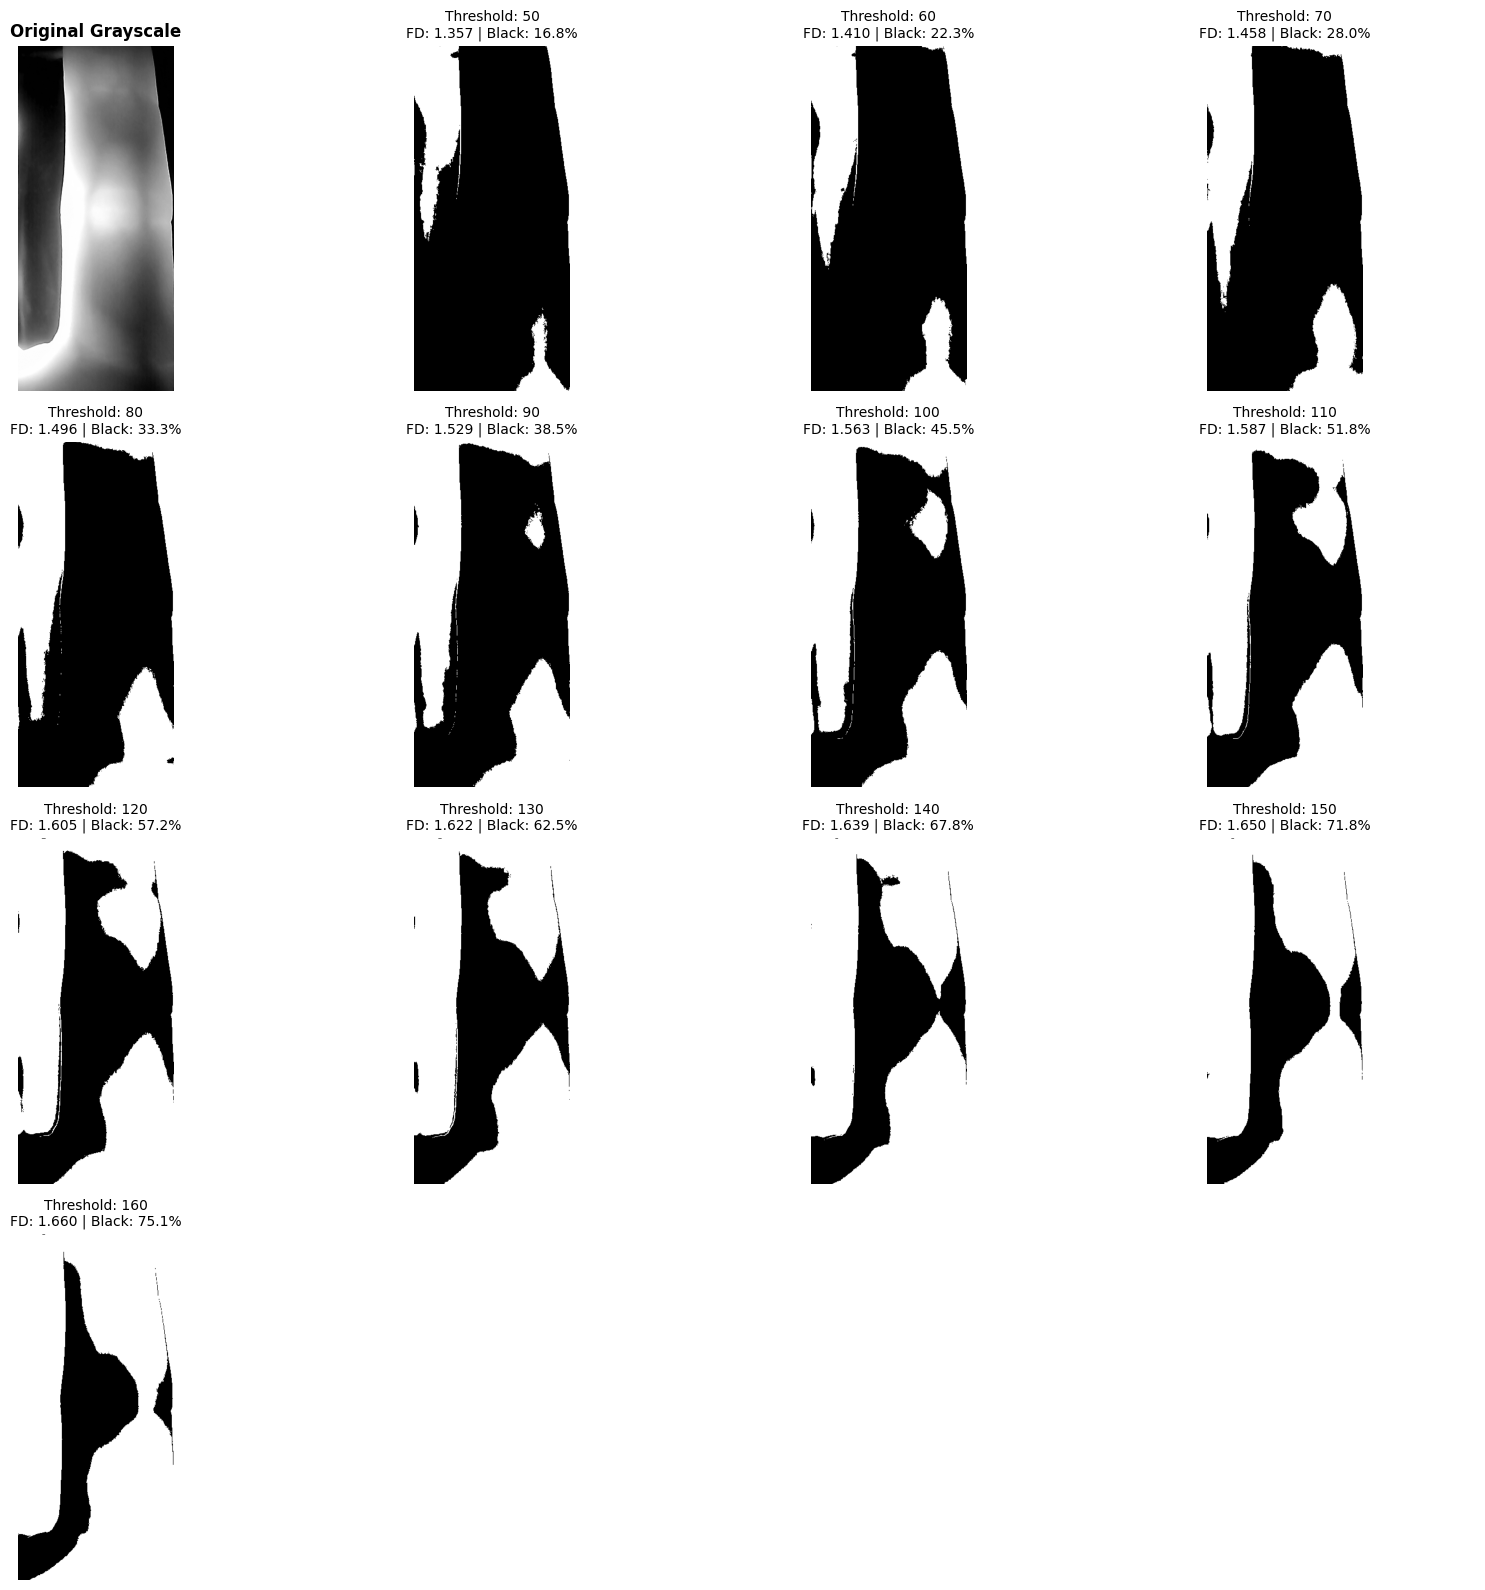

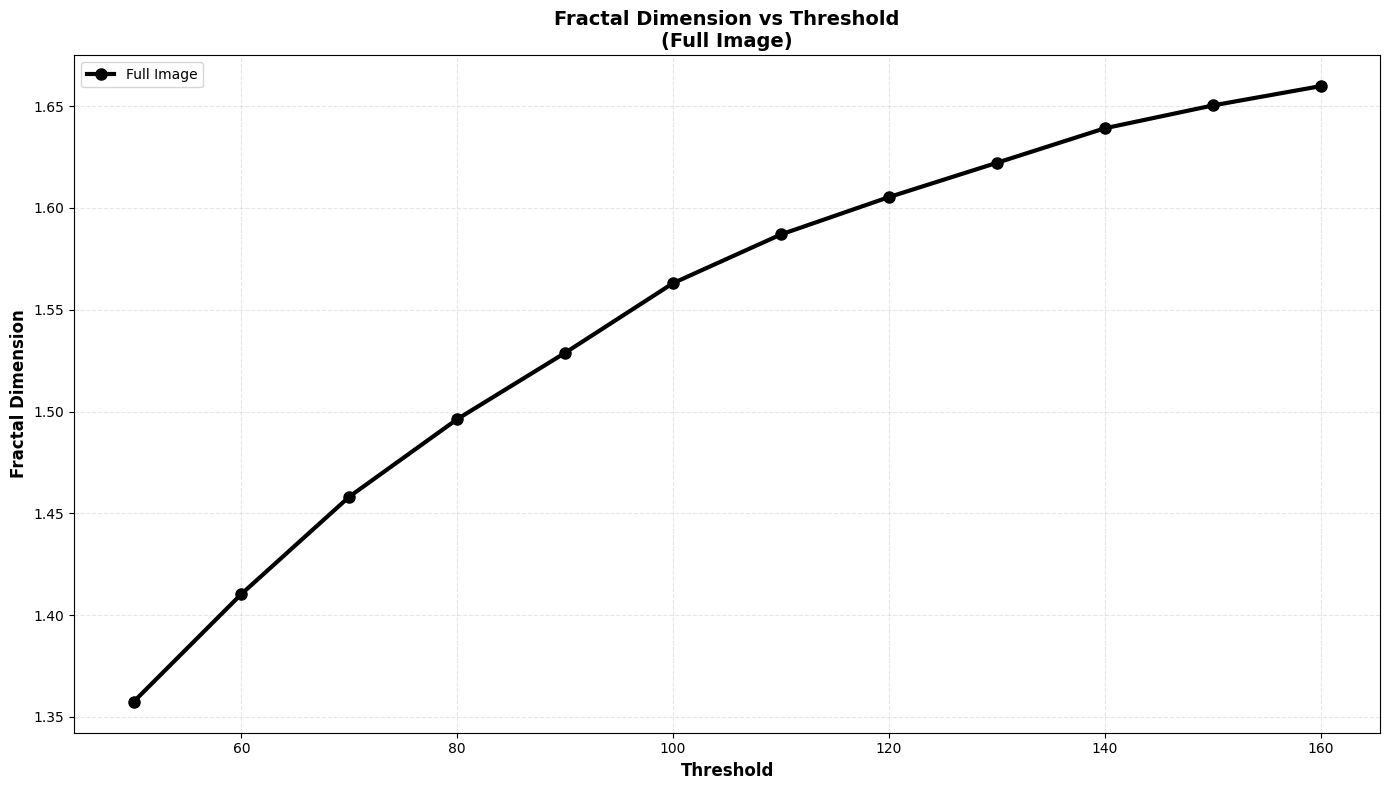

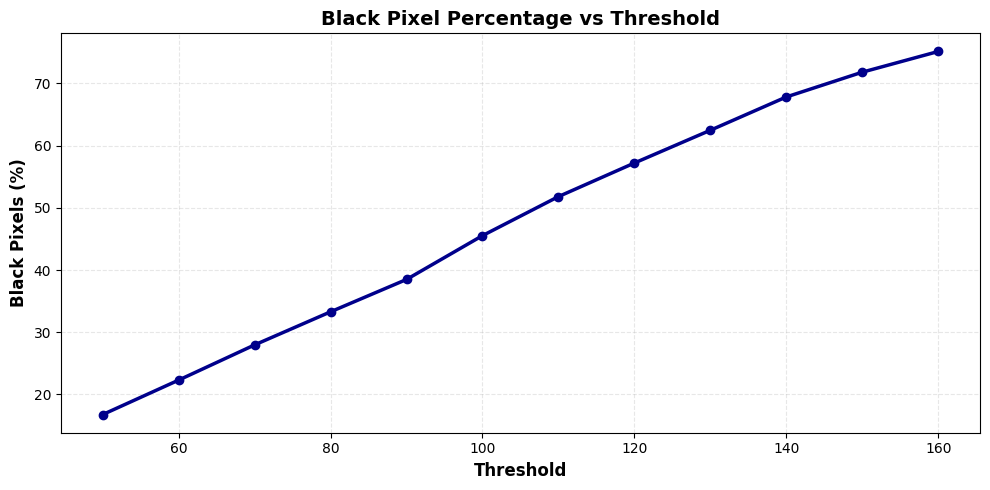

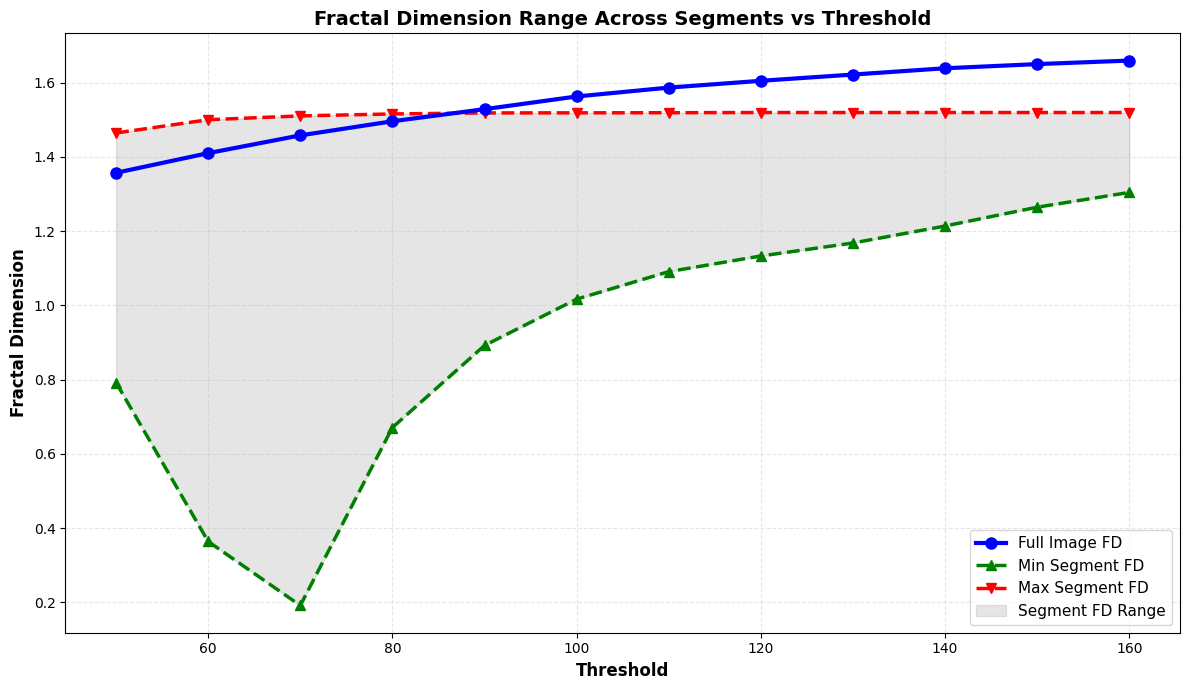

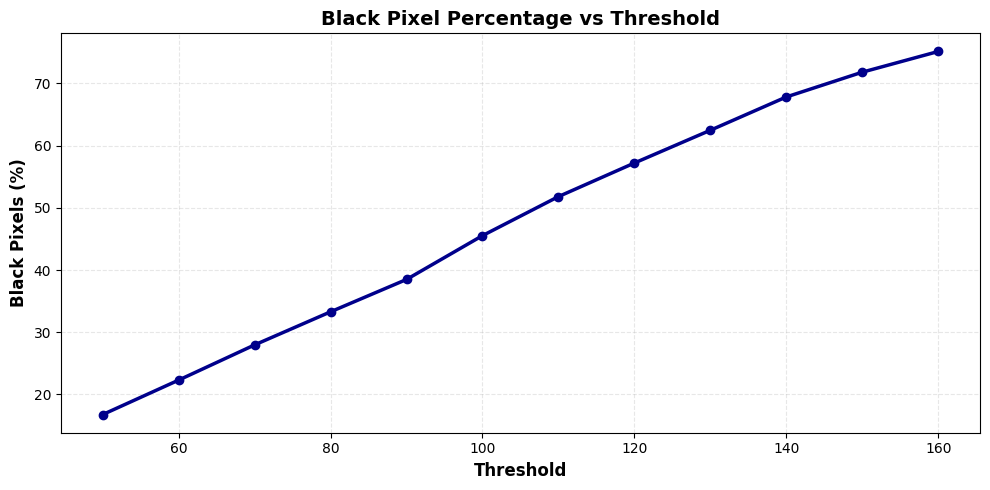

FRACTAL DIMENSION ANALYSIS WITH THRESHOLD VARIATION
Image loaded: /content/drive/MyDrive/SCUT/full/train/spoof/14/14_1_0_0_3.bmp
Image size: (640, 288)
Value range: 13 - 239
Method: Standard Box-Counting

Processing 12 thresholds...
  Threshold:  50 | FD Full: 1.5605 | FD Segs: [1.485, 1.154, 1.252, 1.437] [1.346, 1.172, 1.361, 1.446] | Black: 47.0%
  Threshold:  60 | FD Full: 1.5850 | FD Segs: [1.494, 1.190, 1.362, 1.449] [1.373, 1.222, 1.400, 1.462] | Black: 53.2%
  Threshold:  70 | FD Full: 1.6103 | FD Segs: [1.501, 1.252, 1.441, 1.457] [1.406, 1.273, 1.432, 1.477] | Black: 59.4%
  Threshold:  80 | FD Full: 1.6236 | FD Segs: [1.507, 1.305, 1.457, 1.463] [1.424, 1.291, 1.447, 1.489] | Black: 63.9%
  Threshold:  90 | FD Full: 1.6350 | FD Segs: [1.510, 1.339, 1.470, 1.469] [1.440, 1.322, 1.461, 1.497] | Black: 67.6%
  Threshold: 100 | FD Full: 1.6441 | FD Segs: [1.512, 1.368, 1.484, 1.475] [1.454, 1.351, 1.472, 1.501] | Black: 70.5%
  Threshold: 110 | FD Full: 1.6518 | FD Segs: [1.513,

,threshold,fractal_dimension,black_pixels_percent,fractal_dimension_seg1,fractal_dimension_seg2,fractal_dimension_seg3,fractal_dimension_seg4,fractal_dimension_seg5,fractal_dimension_seg6,fractal_dimension_seg7,fractal_dimension_seg8
0,50,1.560480,47.010091,1.484934,1.154337,1.252358,1.437114,1.345914,1.172188,1.360884,1.445732
1,60,1.585012,53.184136,1.493625,1.190162,1.361507,1.449003,1.372692,1.221944,1.400081,1.462280
2,70,1.610297,59.374457,1.500581,1.251613,1.441299,1.457099,1.405809,1.272901,1.431501,1.477105
3,80,1.623565,63.943685,1.507271,1.305143,1.457199,1.463216,1.423504,1.291342,1.446708,1.488763
4,90,1.634979,67.623155,1.510445,1.338965,1.469862,1.469207,1.439750,1.321526,1.460887,1.497107
5,100,1.644122,70.509983,1.512237,1.367515,1.483776,1.474790,1.453860,1.351049,1.472156,1.501117
6,110,1.651819,73.203668,1.512755,1.388334,1.497733,1.481089,1.457805,1.370060,1.482005,1.507991
7,120,1.658769,75.596788,1.513099,1.406740,1.426473,1.486488,1.463175,1.383840,1.489410,1.512622
8,130,1.666336,78.103299,1.513099,1.420653,1.442175,1.496317,1.465990,1.403031,1.497267,1.518141
9,140,1.672839,80.591363,1.513184,1.431383,1.455810,1.505816,1.471320,1.418613,1.504693,1.519390



VISUALIZATIONS:

1. Binary Images at Different Thresholds:


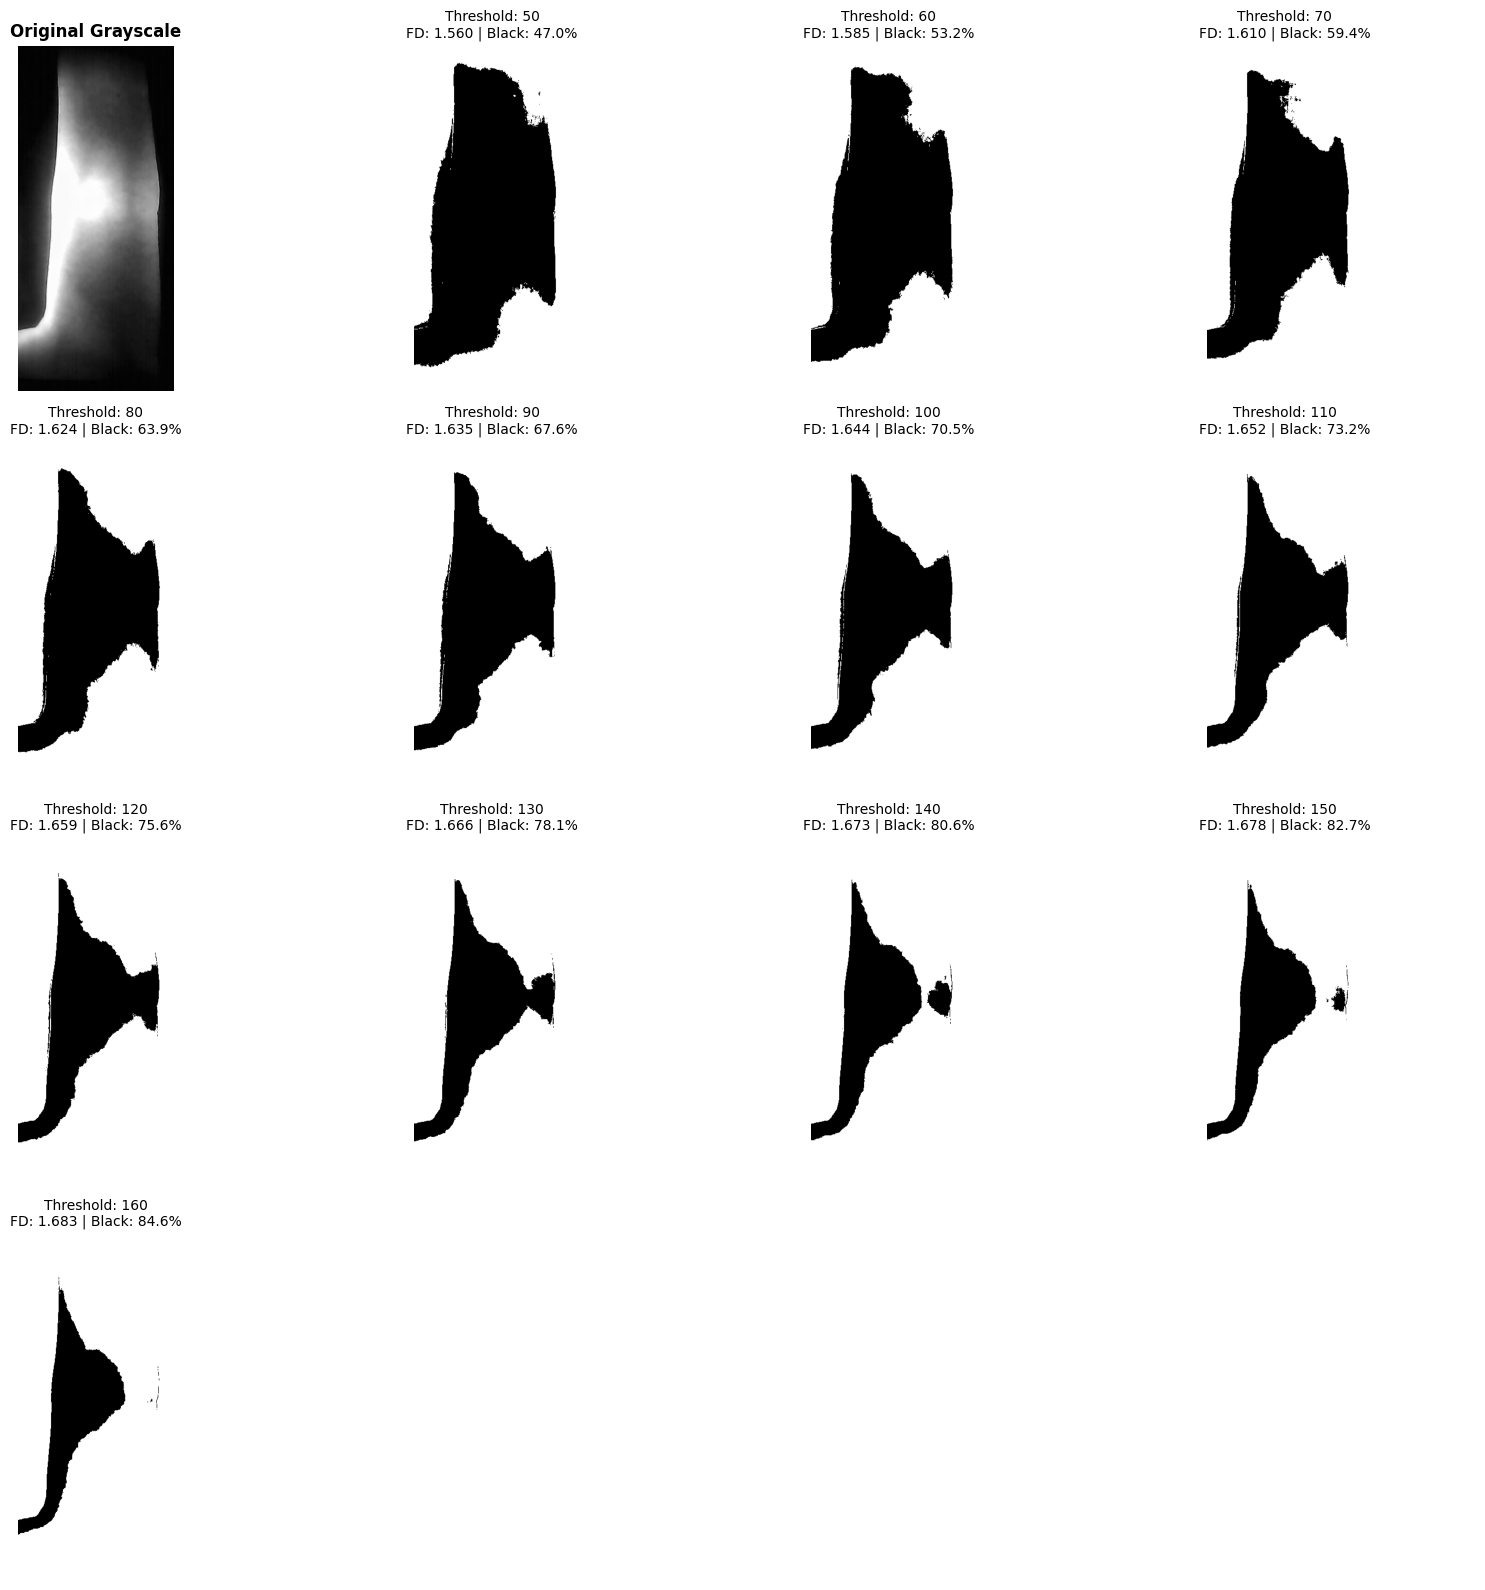

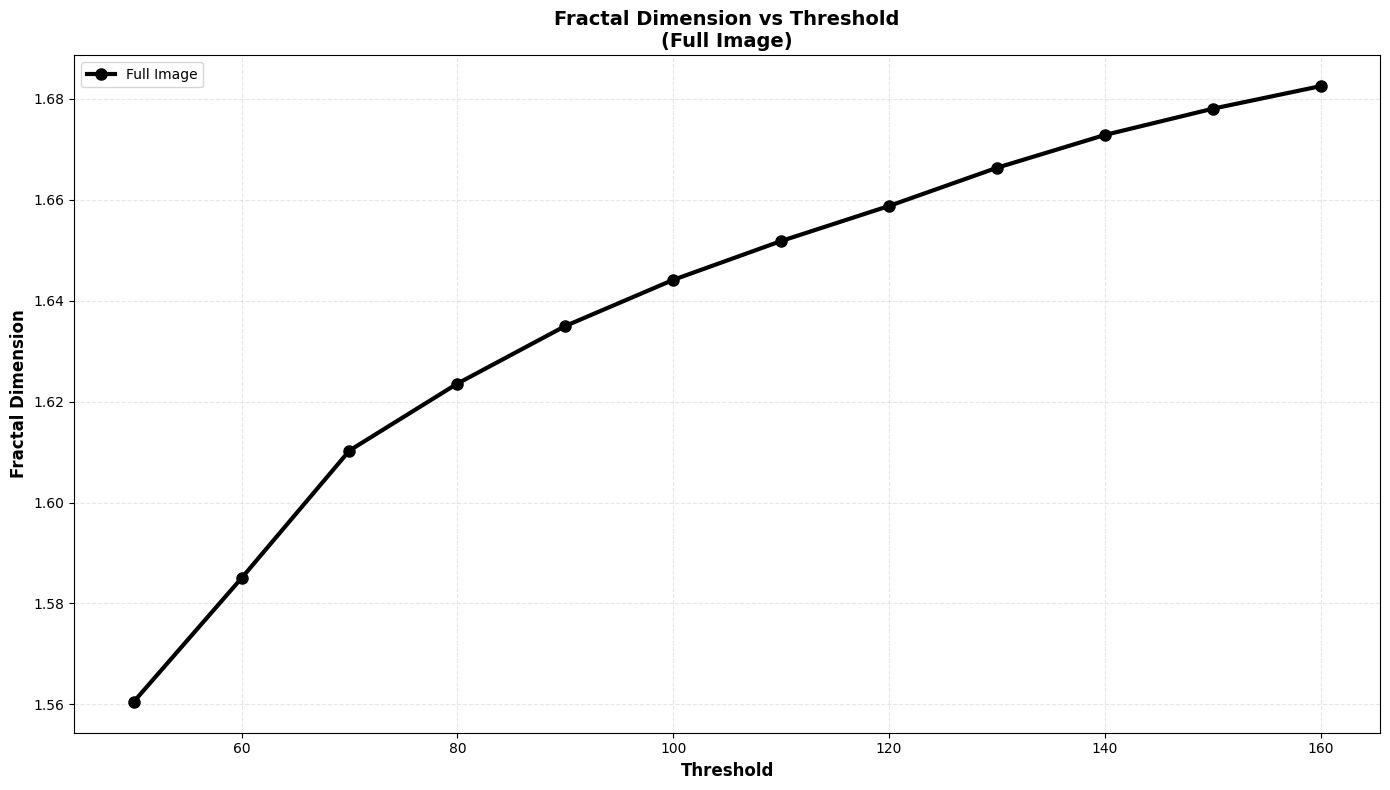

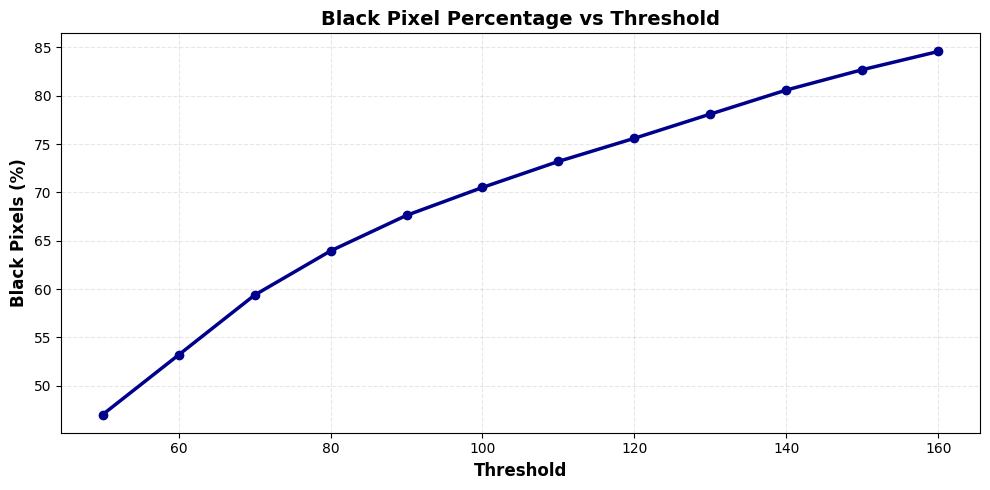

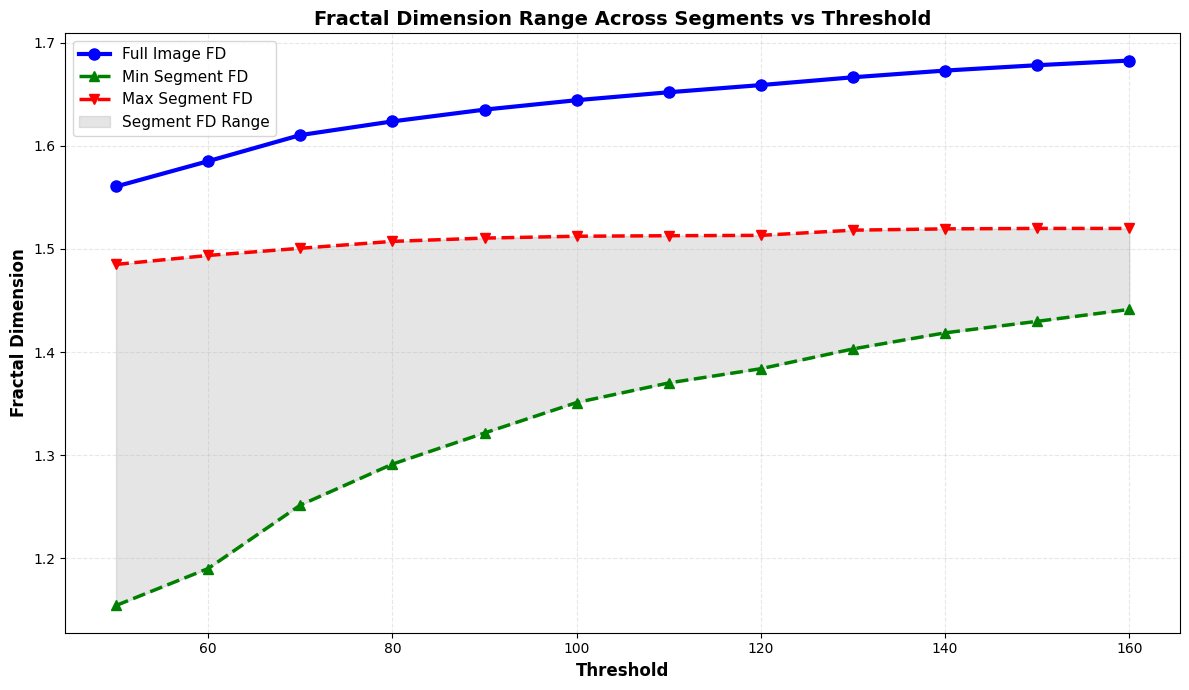

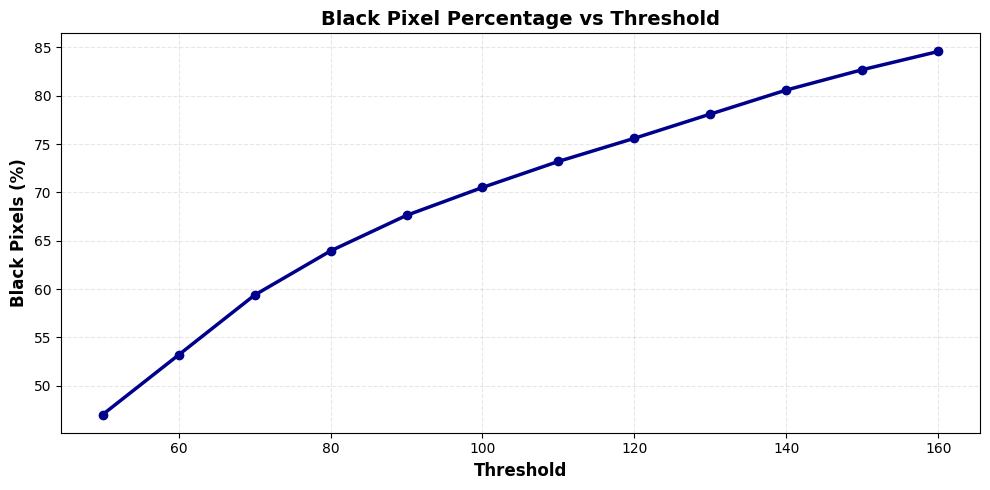

In [14]:
if __name__ == "__main__":
    # Input: Grayscale image file path
    #image_path = "Users/rajani/Documents/Uni_Studies/Image_Processing_Imaging/Data_FV_Spoofing_WS2025_26/PLUS/real/001/PLUS-FV3-Laser_PALMAR_001_01_07_02.png"  # CHANGE THIS
    #image_path_spoof = "/content/PLUS-FV3-Laser_PALMAR_006_01_02_02.png"
    #image_path_real = "/content/PLUS-FV3-Laser_PALMAR_047_01_09_01.png"

    image_path_real = "/content/drive/MyDrive/SCUT/full/train/real/14/14_1_0_0_5.bmp"
    image_path_spoof = "/content/drive/MyDrive/SCUT/full/train/spoof/14/14_1_0_0_3.bmp"

    # Optional: Define custom thresholds (0-255 scale)
    # If None, will use default range from 50 to 200 in 10 steps
    custom_thresholds = np.linspace(50, 160, 12)  # 12 thresholds from 30 to 220

    # Run complete analysis
    results_df_real = main_analysis(image_path_real, thresholds=custom_thresholds)
    plot_fractal_dimensions(results_df_real)
    results_df_spoof = main_analysis(image_path_spoof, thresholds=custom_thresholds)
    plot_fractal_dimensions(results_df_spoof)

## **Rajani : Plots graphs for 50 real and spoof images between image name and FD at different thresholds**

In [15]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from google.colab import drive
from PIL import Image
import cv2

# ============================================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================================

def mount_drive():
    """Mount Google Drive in Colab."""
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
    print("✓ Drive mounted successfully!")


# ============================================================================
# 2. FRACTAL DIMENSION CALCULATION (BOX-COUNTING METHOD)
# ============================================================================

def box_count(binary_image, box_size):
    """
    Count the number of boxes needed to cover the image at a given box size.

    Args:
        binary_image: Binary image (0s and 1s)
        box_size: Size of the box

    Returns:
        Number of boxes containing at least one foreground pixel
    """
    h, w = binary_image.shape
    count = 0

    # Iterate over the image with the given box size
    for i in range(0, h, box_size):
        for j in range(0, w, box_size):
            # Extract the box
            box = binary_image[i:min(i+box_size, h), j:min(j+box_size, w)]
            # Check if box contains any foreground pixels
            if np.any(box):
                count += 1

    return count


def calculate_fractal_dimension(binary_image):
    """
    Calculate fractal dimension using box-counting method.

    Args:
        binary_image: Binary image (numpy array with 0s and 1s)

    Returns:
        Fractal dimension value
    """
    # Generate box sizes (powers of 2 work well)
    max_dim = min(binary_image.shape)
    box_sizes = []
    size = 2
    while size <= max_dim // 4:
        box_sizes.append(size)
        size *= 2

    if len(box_sizes) < 3:
        # If image is too small, use a different range
        box_sizes = [2, 4, 8, 16, 32, 64]
        box_sizes = [s for s in box_sizes if s <= max_dim // 2]

    # Count boxes for each size
    counts = []
    for box_size in box_sizes:
        count = box_count(binary_image, box_size)
        counts.append(count)

    # Convert to log scale
    log_sizes = np.log(1.0 / np.array(box_sizes))
    log_counts = np.log(counts)

    # Fit a line: log(count) = fractal_dim * log(1/size) + intercept
    # Using linear regression
    coeffs = np.polyfit(log_sizes, log_counts, 1)
    fractal_dim = coeffs[0]

    return fractal_dim


# ============================================================================
# 3. IMAGE PROCESSING AND ANALYSIS
# ============================================================================

def load_and_convert_to_grayscale(image_path):
    """
    Load an image and convert to grayscale.

    Args:
        image_path: Path to image file

    Returns:
        Grayscale numpy array
    """
    # Try loading with PIL first
    try:
        img = Image.open(image_path)
        # Convert to grayscale
        if img.mode != 'L':
            img = img.convert('L')
        gray_img = np.array(img)
        return gray_img
    except Exception as e:
        # Fallback to OpenCV
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Could not load image: {image_path}")
        return img


def apply_threshold_and_calculate_fd(gray_image, threshold):
    """
    Apply threshold to grayscale image and calculate fractal dimension.

    Args:
        gray_image: Grayscale image (numpy array)
        threshold: Threshold value (0-255)

    Returns:
        tuple: (fractal_dimension, black_pixels_percent)
    """
    # Apply threshold
    binary_image = (gray_image > threshold).astype(np.uint8)

    # Calculate black pixel percentage
    black_pixels_percent = (1 - np.mean(binary_image)) * 100

    # Calculate fractal dimension
    if np.any(binary_image):
        fractal_dim = calculate_fractal_dimension(binary_image)
    else:
        fractal_dim = 0.0  # No foreground pixels

    return fractal_dim, black_pixels_percent


def analyze_image_with_thresholds(image_path, thresholds):
    """
    Analyze a single image with multiple thresholds.

    Args:
        image_path: Path to image file
        thresholds: List of threshold values

    Returns:
        dict: Results for all thresholds
    """
    # Load grayscale image
    gray_image = load_and_convert_to_grayscale(image_path)

    results = {}

    for threshold in thresholds:
        fd, black_percent = apply_threshold_and_calculate_fd(gray_image, threshold)
        results[f'fd_thresh_{threshold}'] = fd
        results[f'black_percent_thresh_{threshold}'] = black_percent

    return results


# ============================================================================
# 4. FIND AND PROCESS IMAGES
# ============================================================================

def get_random_images(base_path, num_images=50):
    """
    Find and return random image files from the directory structure.

    Args:
        base_path: Base path like "/content/PLUS/real"
        num_images: Number of random images to sample

    Returns:
        List of tuples: (file_path, file_name)
    """
    print(f"Searching for images in: {base_path}")

    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif']
    all_images = []

    base_dir = Path(base_path)

    if not base_dir.exists():
        raise FileNotFoundError(f"Directory not found: {base_path}")

    # Walk through numbered subdirectories
    for number_dir in base_dir.iterdir():
        if number_dir.is_dir():
            for file_path in number_dir.iterdir():
                if file_path.is_file() and file_path.suffix.lower() in image_extensions:
                    all_images.append((str(file_path), file_path.name))

    print(f"Found {len(all_images)} total images")

    # Sample random images
    if len(all_images) > num_images:
        selected_images = random.sample(all_images, num_images)
    else:
        print(f"Warning: Only {len(all_images)} images found, using all of them")
        selected_images = all_images

    print(f"Selected {len(selected_images)} random images")
    return selected_images


def process_all_images(image_list, thresholds):
    """
    Process all images with multiple thresholds.

    Args:
        image_list: List of (file_path, file_name) tuples
        thresholds: List of threshold values

    Returns:
        pd.DataFrame: Results for all images and thresholds
    """
    print(f"\nProcessing {len(image_list)} images with thresholds: {thresholds}")

    results_list = []

    for idx, (file_path, file_name) in enumerate(image_list, 1):
        print(f"  [{idx}/{len(image_list)}] Processing: {file_name}")

        try:
            # Analyze image with all thresholds
            results = analyze_image_with_thresholds(file_path, thresholds)

            # Add metadata
            results['filename'] = file_name
            results['filepath'] = file_path

            results_list.append(results)

        except Exception as e:
            print(f"    ✗ Error processing {file_name}: {e}")
            continue

    # Create DataFrame
    df = pd.DataFrame(results_list)

    # Reorder columns
    metadata_cols = ['filename', 'filepath']
    other_cols = [col for col in df.columns if col not in metadata_cols]
    df = df[metadata_cols + sorted(other_cols)]

    print(f"\n✓ Successfully processed {len(df)} images")
    return df


# ============================================================================
# 5. VISUALIZATION
# ============================================================================

def plot_fractal_dimensions(results_df, thresholds):
    """
    Create comprehensive visualizations of fractal dimensions.

    Args:
        results_df: DataFrame with analysis results
        thresholds: List of threshold values used
    """
    sns.set_style("whitegrid")

    # Prepare data for plotting
    num_images = len(results_df)
    x_pos = np.arange(num_images)

    # ========================================================================
    # Plot 1: Main Line Plot - Fractal Dimension vs Filename for all thresholds
    # ========================================================================
    plt.figure(figsize=(18, 8))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    markers = ['o', 's', '^', 'D']

    for idx, threshold in enumerate(thresholds):
        col_name = f'fd_thresh_{threshold}'
        plt.plot(x_pos, results_df[col_name],
                marker=markers[idx % len(markers)],
                linewidth=2,
                markersize=6,
                label=f'Threshold {threshold}',
                color=colors[idx % len(colors)],
                alpha=0.7)

    plt.xlabel('Image Index', fontsize=14, fontweight='bold')
    plt.ylabel('Fractal Dimension', fontsize=14, fontweight='bold')
    plt.title('Fractal Dimension vs Images (Different Thresholds)',
              fontsize=16, fontweight='bold')
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)

    # Show filenames if not too many
    if num_images <= 25:
        plt.xticks(x_pos, results_df['filename'], rotation=90, fontsize=8)
    else:
        plt.xlabel('Image Index', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('fractal_dimension_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ========================================================================
    # Plot 2: Box Plot - Distribution by Threshold
    # ========================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Prepare data for box plot
    fd_data = []
    threshold_labels = []

    for threshold in thresholds:
        col_name = f'fd_thresh_{threshold}'
        fd_data.append(results_df[col_name].values)
        threshold_labels.append(f'T={threshold}')

    # Box plot
    bp = ax1.boxplot(fd_data, labels=threshold_labels, patch_artist=True)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Fractal Dimension', fontsize=12, fontweight='bold')
    ax1.set_title('Fractal Dimension Distribution by Threshold',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # Violin plot
    for idx, threshold in enumerate(thresholds):
        col_name = f'fd_thresh_{threshold}'
        parts = ax2.violinplot([results_df[col_name].values],
                               positions=[idx],
                               showmeans=True,
                               showmedians=True)

        for pc in parts['bodies']:
            pc.set_facecolor(colors[idx % len(colors)])
            pc.set_alpha(0.7)

    ax2.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Fractal Dimension', fontsize=12, fontweight='bold')
    ax2.set_title('Fractal Dimension Distribution (Violin Plot)',
                  fontsize=14, fontweight='bold')
    ax2.set_xticks(range(len(thresholds)))
    ax2.set_xticklabels([f'T={t}' for t in thresholds])
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('fractal_dimension_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ========================================================================
    # Plot 3: Heatmap - All Images vs All Thresholds
    # ========================================================================
    plt.figure(figsize=(12, max(8, num_images * 0.3)))

    # Prepare heatmap data
    heatmap_data = []
    for threshold in thresholds:
        col_name = f'fd_thresh_{threshold}'
        heatmap_data.append(results_df[col_name].values)

    heatmap_data = np.array(heatmap_data)

    # Create heatmap
    im = plt.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', interpolation='nearest')

    plt.xlabel('Image Index', fontsize=12, fontweight='bold')
    plt.ylabel('Threshold', fontsize=12, fontweight='bold')
    plt.title('Fractal Dimension Heatmap (Threshold vs Images)',
              fontsize=14, fontweight='bold')

    plt.yticks(range(len(thresholds)), [f'T={t}' for t in thresholds])

    if num_images <= 30:
        plt.xticks(range(num_images), results_df['filename'], rotation=90, fontsize=7)

    cbar = plt.colorbar(im, label='Fractal Dimension')

    plt.tight_layout()
    plt.savefig('fractal_dimension_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ========================================================================
    # Plot 4: Statistical Summary
    # ========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Mean comparison
    means = [results_df[f'fd_thresh_{t}'].mean() for t in thresholds]
    stds = [results_df[f'fd_thresh_{t}'].std() for t in thresholds]

    axes[0, 0].bar(range(len(thresholds)), means, yerr=stds,
                   color=colors, alpha=0.7, capsize=5)
    axes[0, 0].set_xlabel('Threshold', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Mean Fractal Dimension', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Mean Fractal Dimension by Threshold', fontsize=14, fontweight='bold')
    axes[0, 0].set_xticks(range(len(thresholds)))
    axes[0, 0].set_xticklabels([f'T={t}' for t in thresholds])
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # Scatter plot: First threshold vs others
    if len(thresholds) >= 2:
        base_col = f'fd_thresh_{thresholds[0]}'
        for idx, threshold in enumerate(thresholds[1:], 1):
            col_name = f'fd_thresh_{threshold}'
            axes[0, 1].scatter(results_df[base_col], results_df[col_name],
                             alpha=0.6, s=50, label=f'T={threshold}',
                             color=colors[idx % len(colors)])

        axes[0, 1].plot([results_df[base_col].min(), results_df[base_col].max()],
                       [results_df[base_col].min(), results_df[base_col].max()],
                       'k--', alpha=0.3, label='y=x')

        axes[0, 1].set_xlabel(f'Fractal Dimension (T={thresholds[0]})',
                             fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Fractal Dimension (Other Thresholds)',
                             fontsize=12, fontweight='bold')
        axes[0, 1].set_title('Fractal Dimension Correlation', fontsize=14, fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

    # Black pixel percentage vs Fractal dimension
    threshold_to_plot = thresholds[0]
    fd_col = f'fd_thresh_{threshold_to_plot}'
    bp_col = f'black_percent_thresh_{threshold_to_plot}'

    axes[1, 0].scatter(results_df[bp_col], results_df[fd_col],
                      alpha=0.6, s=80, color='steelblue', edgecolors='black', linewidth=0.5)
    axes[1, 0].set_xlabel('Black Pixels (%)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Fractal Dimension', fontsize=12, fontweight='bold')
    axes[1, 0].set_title(f'Black Pixels vs Fractal Dimension (T={threshold_to_plot})',
                        fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # Summary statistics table
    axes[1, 1].axis('off')

    summary_data = []
    for threshold in thresholds:
        col_name = f'fd_thresh_{threshold}'
        summary_data.append([
            f'T={threshold}',
            f'{results_df[col_name].mean():.4f}',
            f'{results_df[col_name].std():.4f}',
            f'{results_df[col_name].min():.4f}',
            f'{results_df[col_name].max():.4f}'
        ])

    table = axes[1, 1].table(cellText=summary_data,
                            colLabels=['Threshold', 'Mean', 'Std Dev', 'Min', 'Max'],
                            cellLoc='center',
                            loc='center',
                            bbox=[0, 0.2, 1, 0.6])

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style header
    for i in range(5):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')

    axes[1, 1].set_title('Statistical Summary', fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('fractal_dimension_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================================
# 6. MAIN EXECUTION
# ============================================================================

def process_images(base_path):
    """Main execution function."""

    # Step 1: Mount drive
    mount_drive()

    # Step 2: Configuration
    #base_path = "/content/drive/MyDrive/PLUS/real"  # ADJUST THIS PATH!
    # Or if your data is directly in /content/:
    # base_path = "/content/PLUS/real"

    num_images = 50
    thresholds = [75, 85, 95, 105]

    print("\n" + "="*70)
    print("CONFIGURATION")
    print("="*70)
    print(f"Base path: {base_path}")
    print(f"Number of images: {num_images}")
    print(f"Thresholds: {thresholds}")

    # Step 3: Get random images
    image_list = get_random_images(base_path, num_images)

    # Step 4: Process images
    results_df_real = process_all_images(image_list, thresholds)

    # Step 5: Display results summary
    print("\n" + "="*70)
    print("RESULTS SUMMARY")
    print("="*70)
    print(f"\nDataFrame shape: {results_df_real.shape}")
    print(f"\nFirst few rows:")
    print(results_df_real.head())

    print(f"\nStatistical Summary:")
    for threshold in thresholds:
        col_name = f'fd_thresh_{threshold}'
        print(f"\nThreshold {threshold}:")
        print(f"  Mean: {results_df_real[col_name].mean():.4f}")
        print(f"  Std:  {results_df_real[col_name].std():.4f}")
        print(f"  Min:  {results_df_real[col_name].min():.4f}")
        print(f"  Max:  {results_df_real[col_name].max():.4f}")

    # Step 6: Create visualizations
    plot_fractal_dimensions(results_df_real, thresholds)

    # Step 7: Save results
    results_df_real.to_csv('fractal_analysis_results.csv', index=False)
    print("\n✓ Results saved to: fractal_analysis_results.csv")

    return results_df_real

'''
# ============================================================================
# RUN THE PIPELINE
# ============================================================================

if __name__ == "__main__":
    results_df_real = main()

    print("\n" + "="*70)
    print("ANALYSIS COMPLETE!")
    print("="*70)
    print("\nGenerated files:")
    print("  - fractal_analysis_results.csv")
    print("  - fractal_dimension_comparison.png")
    print("  - fractal_dimension_distributions.png")
    print("  - fractal_dimension_heatmap.png")
    print("  - fractal_dimension_statistics.png")
    print("\nDataFrame 'results_df_real' is ready for further analysis.")
  '''

'\n# ============================================================================\n# RUN THE PIPELINE\n# ============================================================================\n\nif __name__ == "__main__":\n    results_df_real = main()\n\n    print("\n" + "="*70)\n    print("ANALYSIS COMPLETE!")\n    print("="*70)\n    print("\nGenerated files:")\n    print("  - fractal_analysis_results.csv")\n    print("  - fractal_dimension_comparison.png")\n    print("  - fractal_dimension_distributions.png")\n    print("  - fractal_dimension_heatmap.png")\n    print("  - fractal_dimension_statistics.png")\n    print("\nDataFrame \'results_df_real\' is ready for further analysis.")\n  '

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive mounted successfully!

CONFIGURATION
Base path: /content/drive/MyDrive/PLUS/real
Number of images: 50
Thresholds: [75, 85, 95, 105]
Searching for images in: /content/drive/MyDrive/PLUS/real
Found 1800 total images
Selected 50 random images

Processing 50 images with thresholds: [75, 85, 95, 105]
  [1/50] Processing: PLUS-FV3-Laser_PALMAR_057_01_03_05.png
  [2/50] Processing: PLUS-FV3-Laser_PALMAR_060_01_02_04.png
  [3/50] Processing: PLUS-FV3-Laser_PALMAR_051_01_09_02.png
  [4/50] Processing: PLUS-FV3-Laser_PALMAR_041_01_08_02.png
  [5/50] Processing: PLUS-FV3-Laser_PALMAR_043_01_09_01.png
  [6/50] Processing: PLUS-FV3-Laser_PALMAR_003_01_08_05.png
  [7/50] Processing: PLUS-FV3-Laser_PALMAR_003_01_02_05.png
  [8/50] Processing: PLUS-FV3-Laser_PALMAR_055_01_07_01.png
  [9/50] Processing: PLUS-FV3-Laser_PALMAR_058_01_02_05.png
 

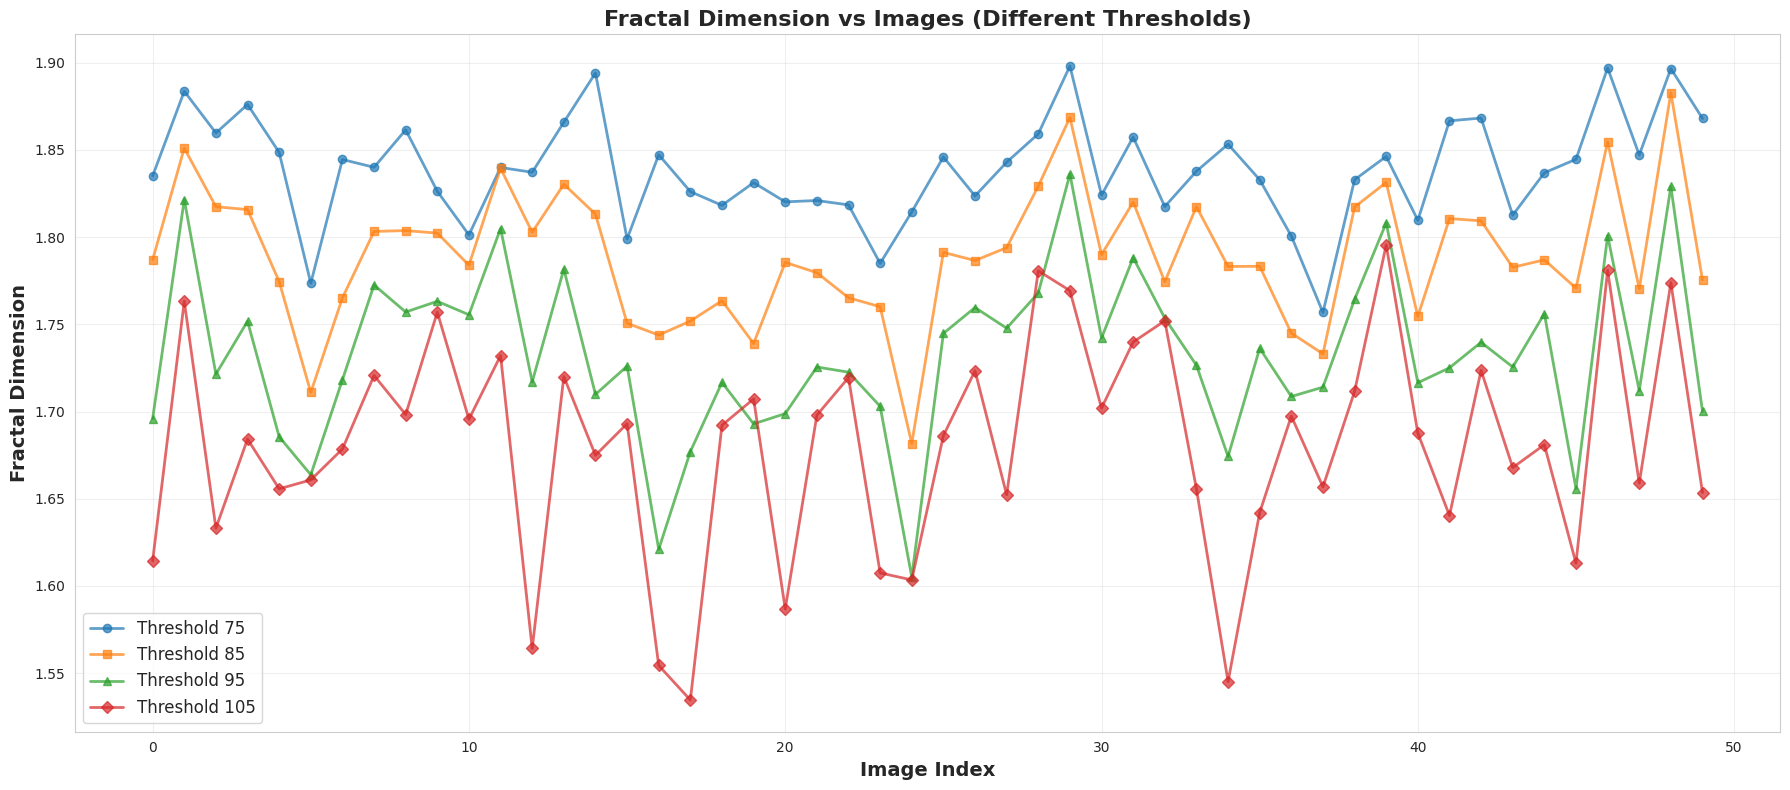

/tmp/ipython-input-164/1048366782.py:331: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(fd_data, labels=threshold_labels, patch_artist=True)


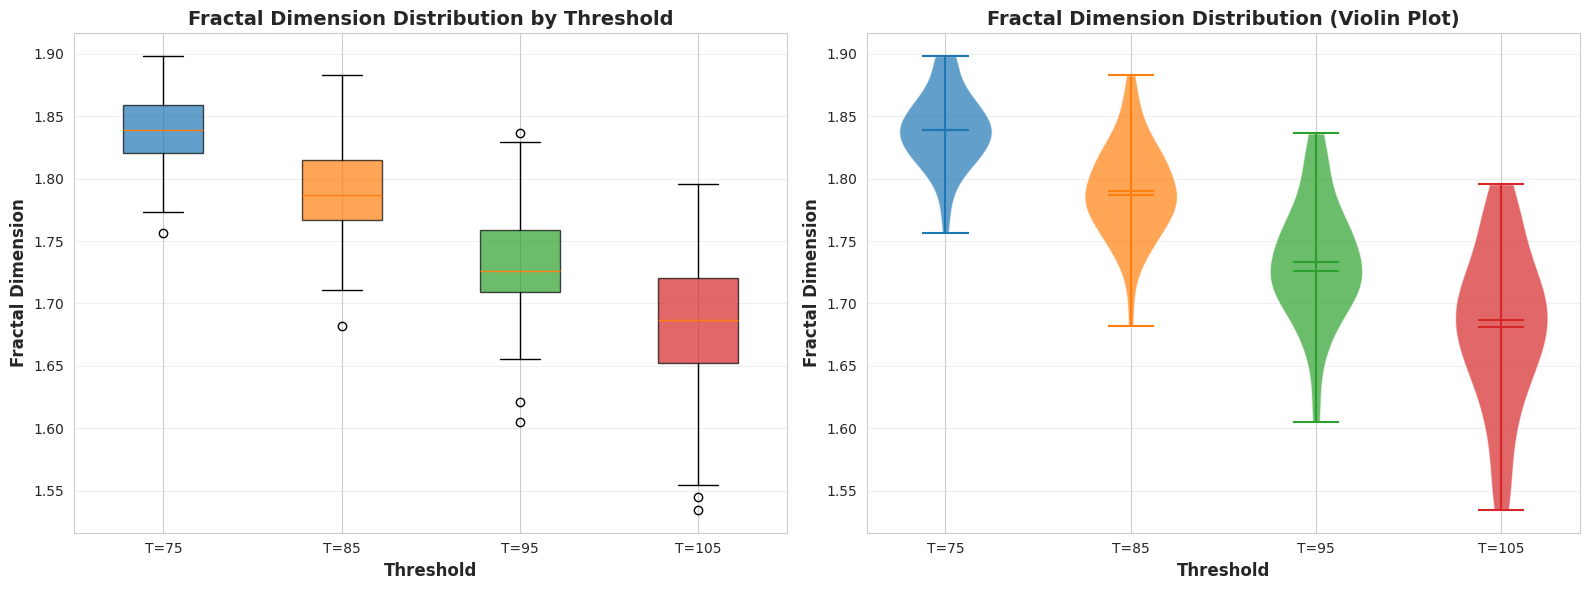

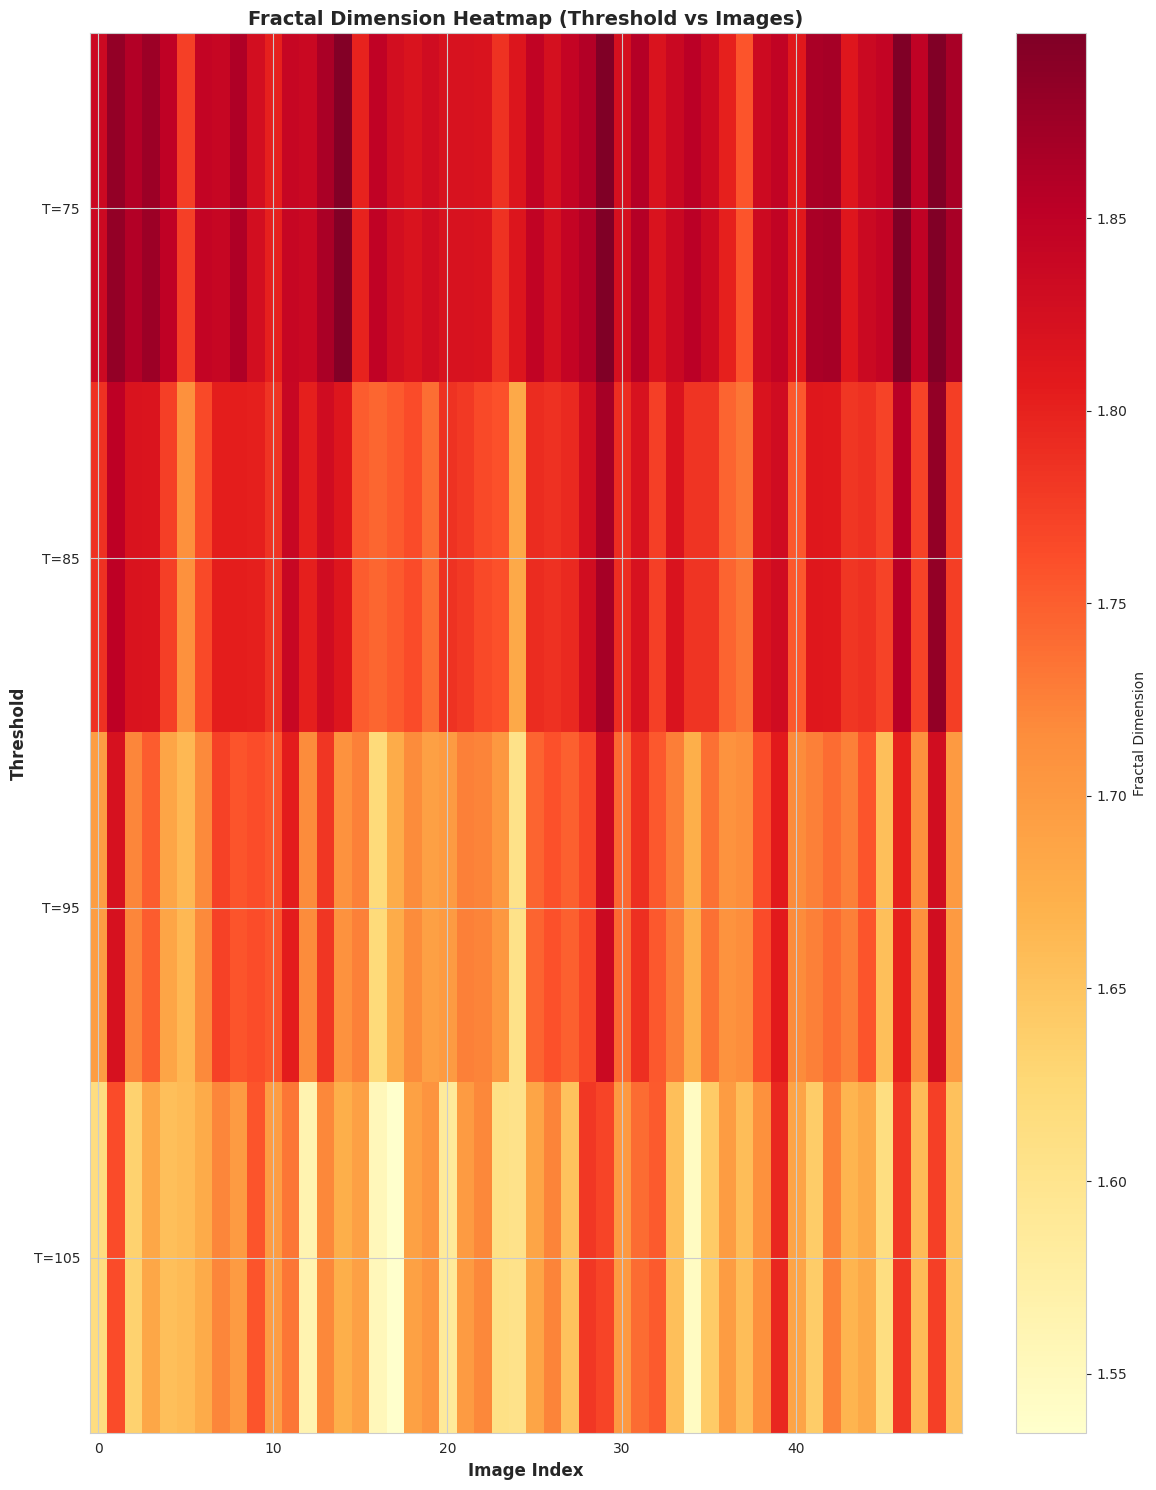

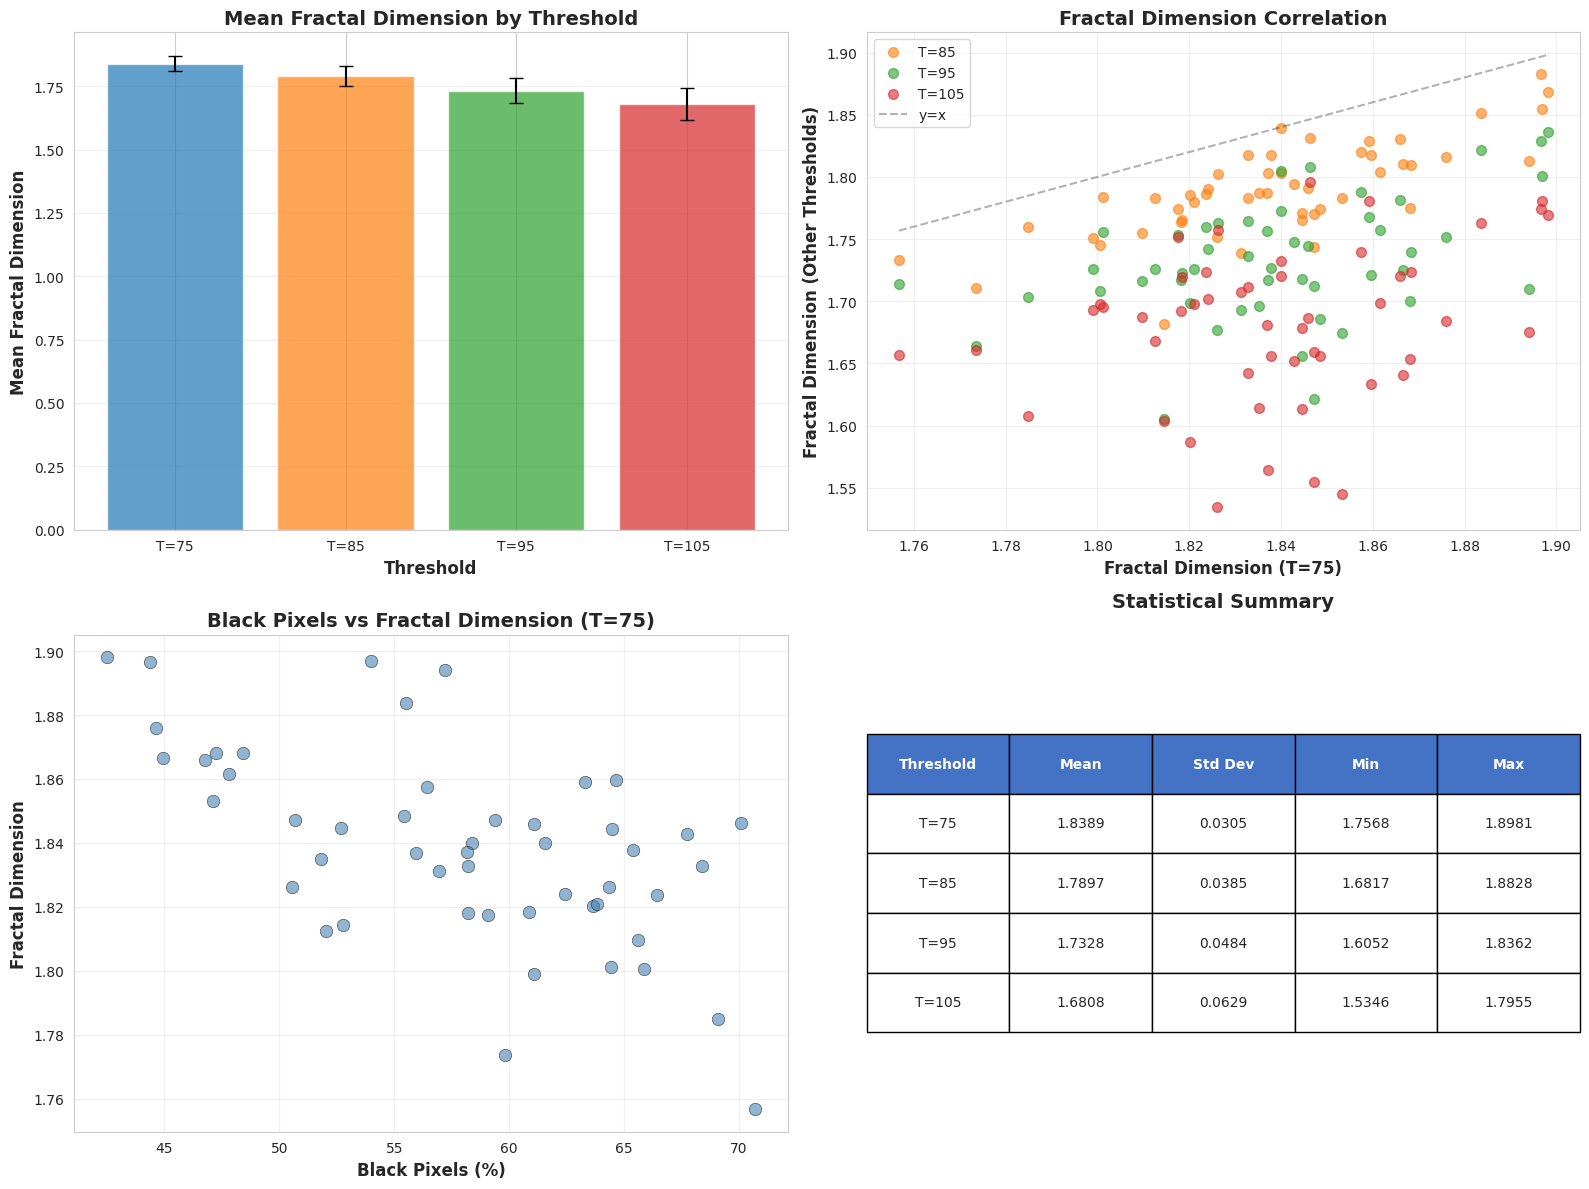


✓ Results saved to: fractal_analysis_results.csv
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive mounted successfully!

CONFIGURATION
Base path: /content/drive/MyDrive/PLUS/spoof
Number of images: 50
Thresholds: [75, 85, 95, 105]
Searching for images in: /content/drive/MyDrive/PLUS/spoof
Found 393 total images
Selected 50 random images

Processing 50 images with thresholds: [75, 85, 95, 105]
  [1/50] Processing: PLUS-FV3-Laser_PALMAR_007_01_02_01.png
  [2/50] Processing: PLUS-FV3-Laser_PALMAR_003_01_03_01.png
  [3/50] Processing: PLUS-FV3-Laser_PALMAR_004_01_09_03.png
  [4/50] Processing: PLUS-FV3-Laser_PALMAR_005_01_07_01.png
  [5/50] Processing: PLUS-FV3-Laser_PALMAR_043_01_03_03.png
  [6/50] Processing: PLUS-FV3-Laser_PALMAR_006_01_02_03.png
  [7/50] Processing: PLUS-FV3-Laser_PALMAR_001_01_07_02.png
  [8/50] Processing: PLUS-FV3-Laser_PALMAR_010_01_07_01.png
  [9/50] P

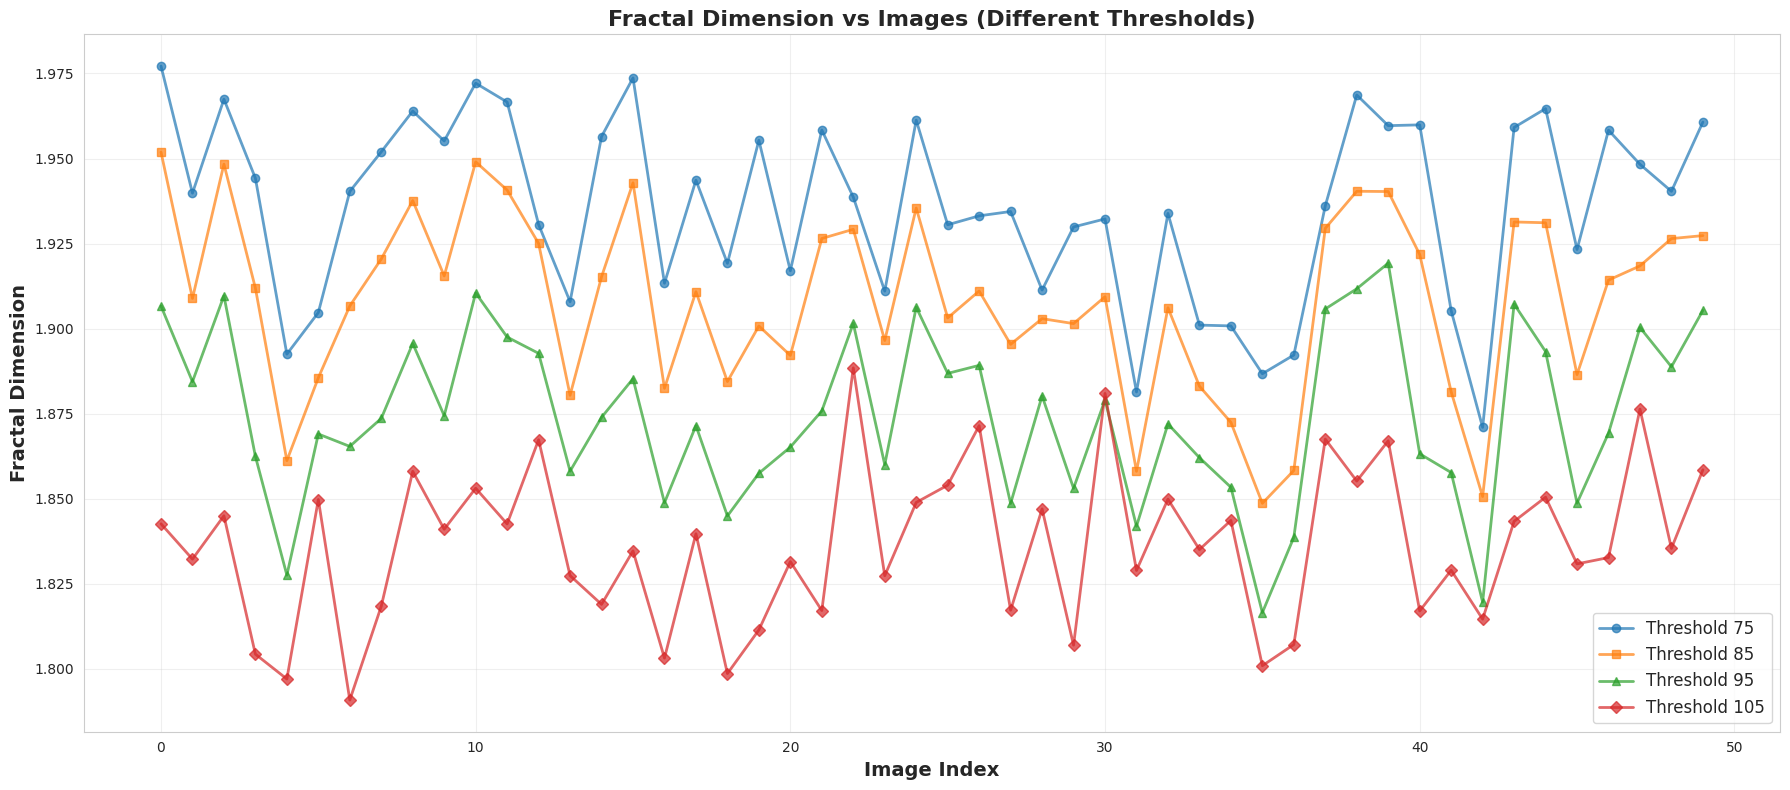

/tmp/ipython-input-164/1048366782.py:331: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(fd_data, labels=threshold_labels, patch_artist=True)


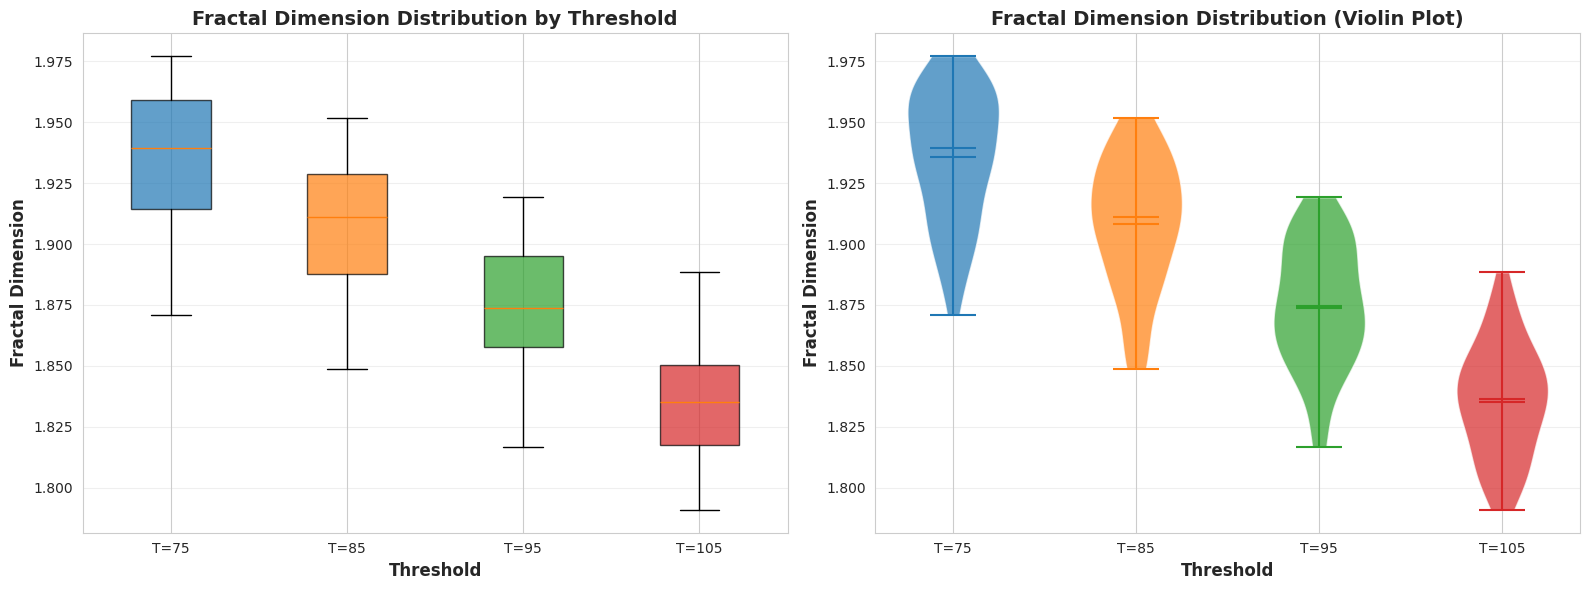

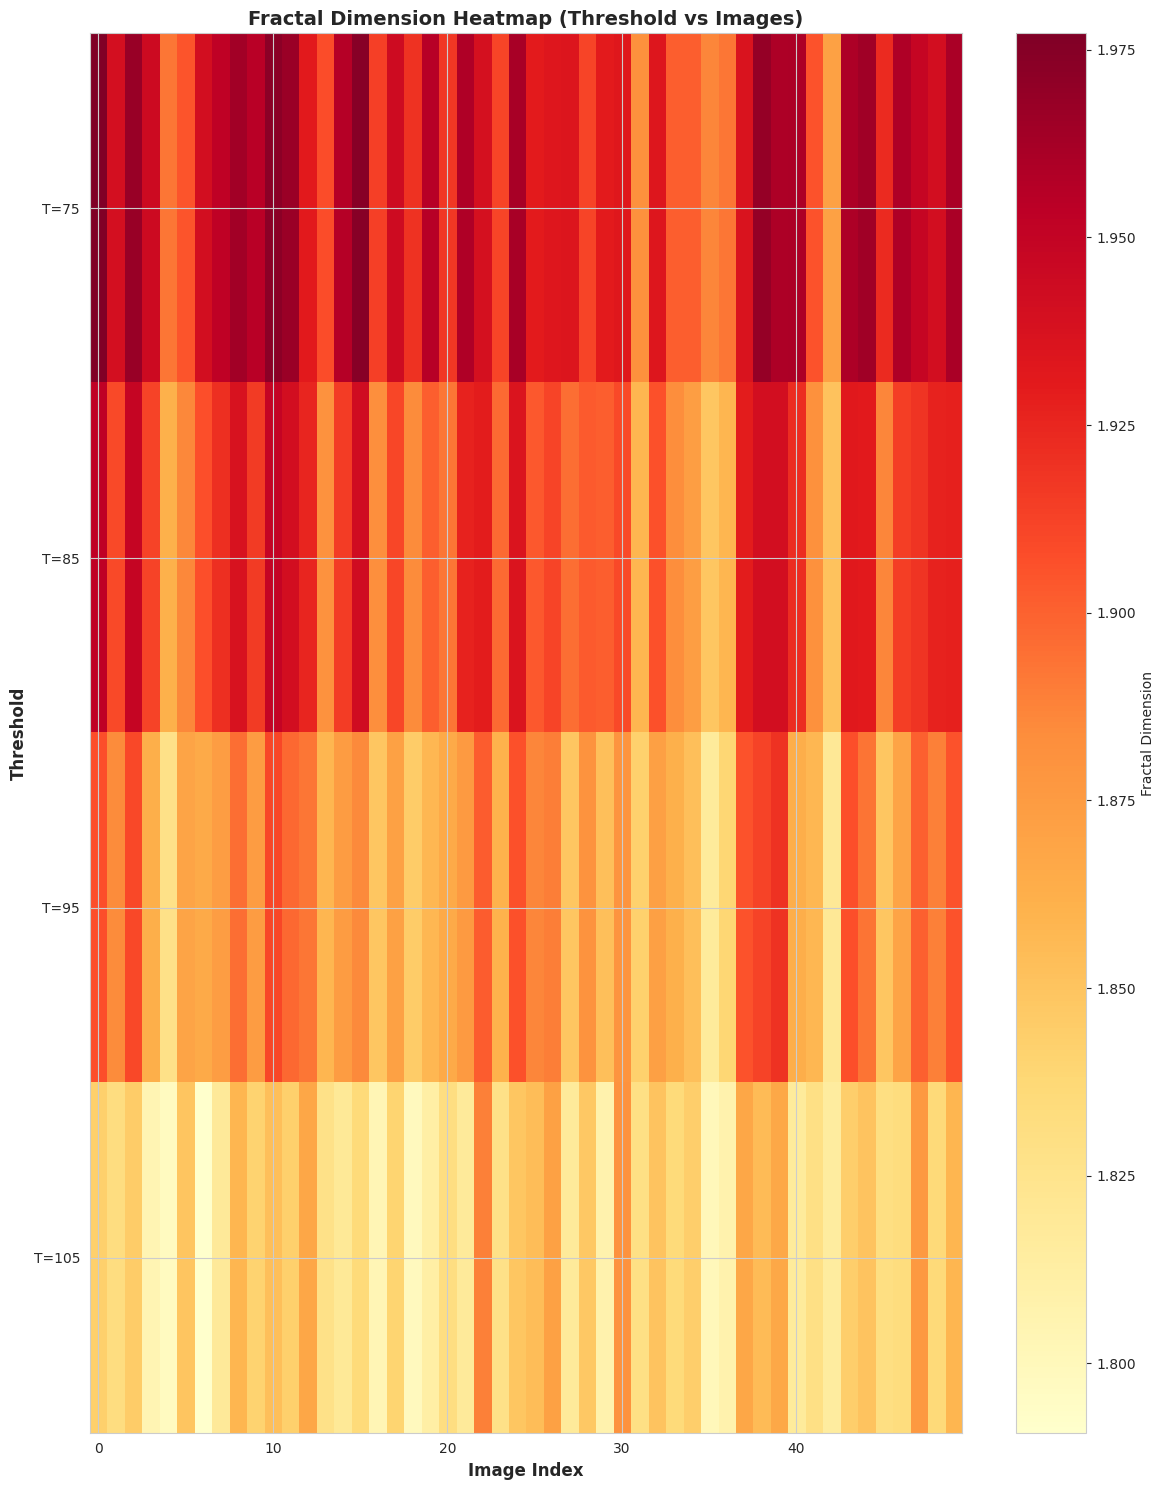

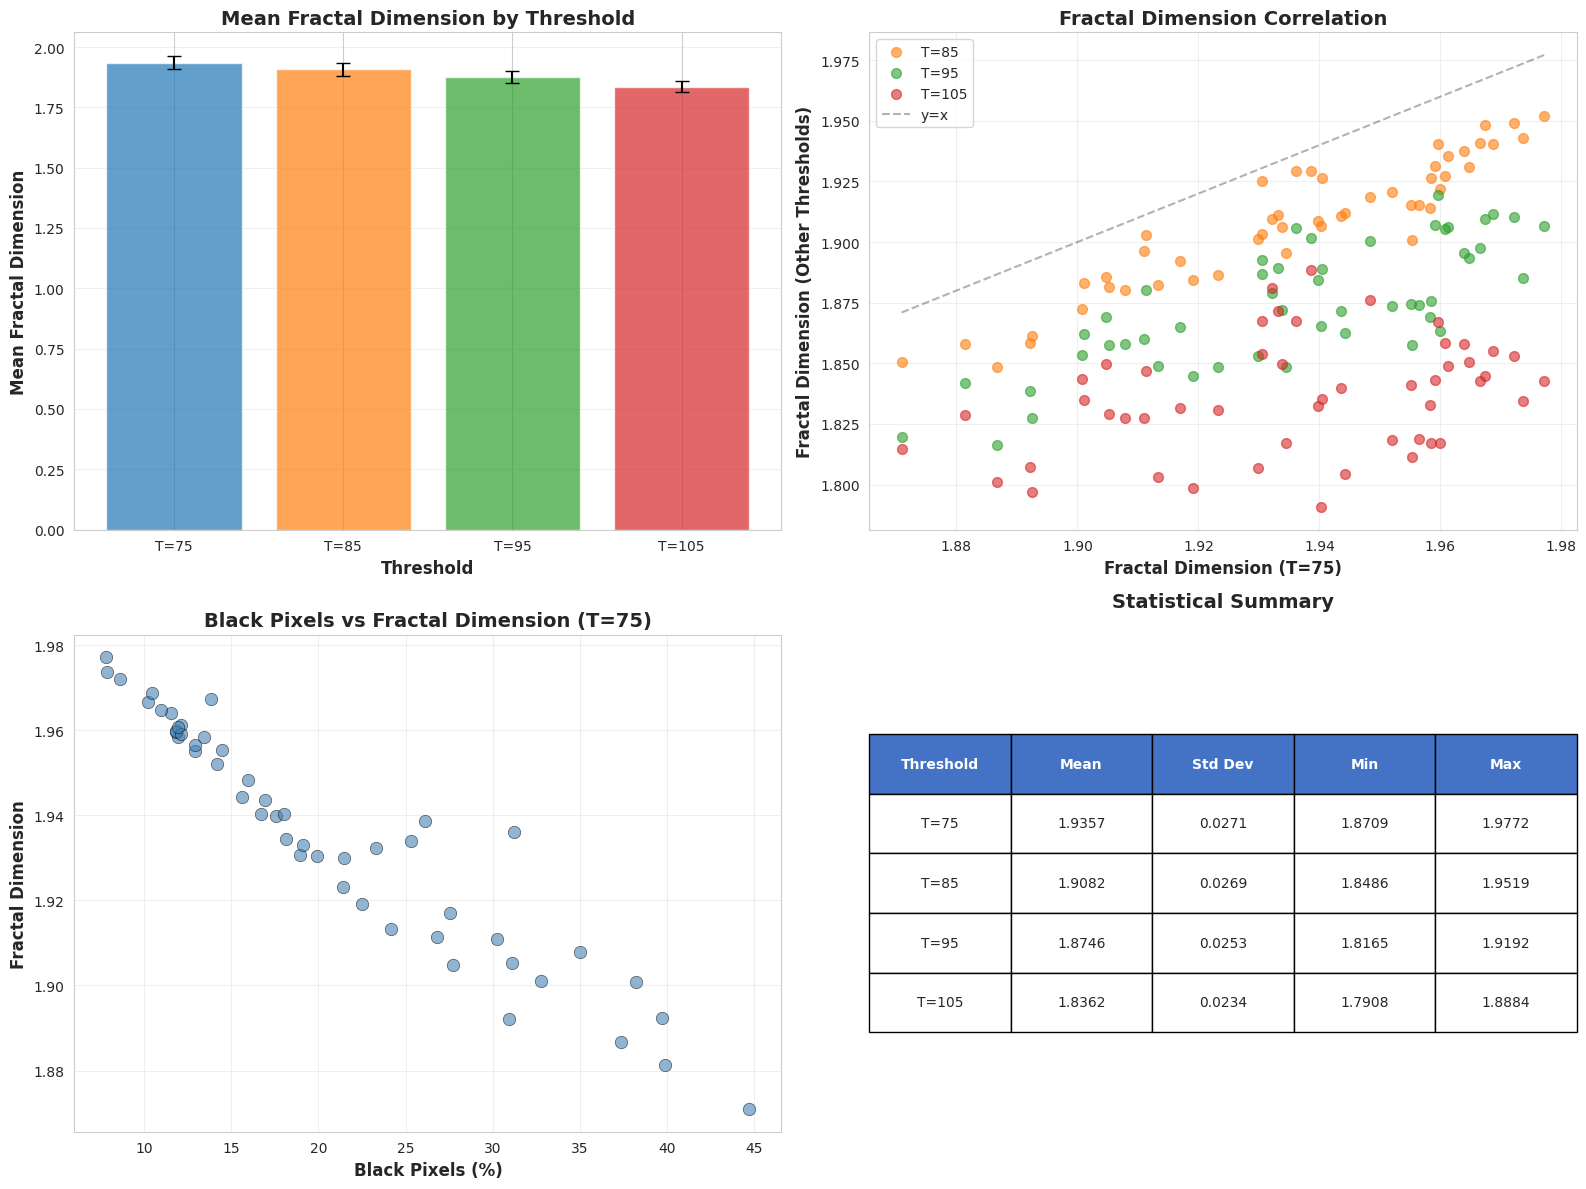


✓ Results saved to: fractal_analysis_results.csv


,filename,filepath,black_percent_thresh_105,black_percent_thresh_75,black_percent_thresh_85,black_percent_thresh_95,fd_thresh_105,fd_thresh_75,fd_thresh_85,fd_thresh_95
0,PLUS-FV3-Laser_PALMAR_007_01_02_01.png,/content/drive/MyDrive/PLUS/spoof/007/PLUS-FV3...,40.025617,7.833730,14.574134,26.074219,1.842577,1.977191,1.951893,1.906619
1,PLUS-FV3-Laser_PALMAR_003_01_03_01.png,/content/drive/MyDrive/PLUS/spoof/003/PLUS-FV3...,50.639012,17.559018,27.648041,38.641446,1.832193,1.939812,1.908855,1.884380
2,PLUS-FV3-Laser_PALMAR_004_01_09_03.png,/content/drive/MyDrive/PLUS/spoof/004/PLUS-FV3...,44.567340,13.820482,21.116395,31.968269,1.844938,1.967447,1.948353,1.909625
3,PLUS-FV3-Laser_PALMAR_005_01_07_01.png,/content/drive/MyDrive/PLUS/spoof/005/PLUS-FV3...,48.290308,15.603063,23.842986,35.721666,1.804244,1.944201,1.911890,1.862418
4,PLUS-FV3-Laser_PALMAR_043_01_03_03.png,/content/drive/MyDrive/PLUS/spoof/043/PLUS-FV3...,64.756709,39.718495,48.736838,56.852214,1.796945,1.892468,1.861157,1.827482
5,PLUS-FV3-Laser_PALMAR_006_01_02_03.png,/content/drive/MyDrive/PLUS/spoof/006/PLUS-FV3...,53.008237,27.746405,37.325209,45.071190,1.849713,1.904709,1.885520,1.868986
6,PLUS-FV3-Laser_PALMAR_001_01_07_02.png,/content/drive/MyDrive/PLUS/spoof/001/PLUS-FV3...,48.759483,16.699219,24.348251,34.682122,1.790761,1.940323,1.906638,1.865336
7,PLUS-FV3-Laser_PALMAR_010_01_07_01.png,/content/drive/MyDrive/PLUS/spoof/010/PLUS-FV3...,45.169554,14.170063,22.927281,33.524400,1.818341,1.951969,1.920451,1.873563
8,PLUS-FV3-Laser_PALMAR_010_01_09_01.png,/content/drive/MyDrive/PLUS/spoof/010/PLUS-FV3...,39.287534,11.548205,18.647390,28.913327,1.858017,1.963948,1.937627,1.895608
9,PLUS-FV3-Laser_PALMAR_015_01_09_03.png,/content/drive/MyDrive/PLUS/spoof/015/PLUS-FV3...,42.692057,12.899825,23.354704,33.992159,1.840990,1.955155,1.915470,1.874366


In [16]:
real_base_path = "/content/drive/MyDrive/PLUS/real"
process_images(real_base_path)
spoof_base_path = "/content/drive/MyDrive/PLUS/spoof"
process_images(spoof_base_path)

#**Rajani : Code to fetch common file names from PLUS/real and PLUS/spoof folder and get FD for an image at different threshold. Feed it to KNN after diving into test and train data.**

In [17]:
# Get common files
import os
import shutil

# Get fractal dimension for all the files and save it in csv file
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
import pandas as pd
from scipy import stats

In [18]:


real_root = "/content/drive/MyDrive/PLUS/real/"
spoof_root = "/content/drive/MyDrive/PLUS/spoof/"
VALID_EXT = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def get_all_files(root):
    """
    Walk the folder and return a dict: filename -> list of full paths
    Handles duplicate filenames in different subfolders.
    """
    fdict = {}
    for base, dirs, files in os.walk(root):
        for f in files:
            ext = os.path.splitext(f.lower())[1]
            if ext in VALID_EXT:
              full = os.path.join(base, f)
              fdict.setdefault(f, []).append(full)
    return fdict

def get_common_files(real_root, spoof_root):

    # Collect all relative file paths
    real_files = get_all_files(real_root)
    spoof_files = get_all_files(spoof_root)
    common_names = set(real_files.keys()) & set(spoof_files.keys())
    return common_names, real_files, spoof_files

common_files, real_path_files, spoof_path_files = (get_common_files(real_root, spoof_root))
common_files_list = list(common_files)
print(len(spoof_path_files))
print (len(real_path_files))
print(len(common_files))
print (real_path_files)
print(spoof_path_files)


393
1800
393
{'PLUS-FV3-Laser_PALMAR_056_01_02_02.png': ['/content/drive/MyDrive/PLUS/real/056/PLUS-FV3-Laser_PALMAR_056_01_02_02.png'], 'PLUS-FV3-Laser_PALMAR_056_01_02_01.png': ['/content/drive/MyDrive/PLUS/real/056/PLUS-FV3-Laser_PALMAR_056_01_02_01.png'], 'PLUS-FV3-Laser_PALMAR_056_01_02_03.png': ['/content/drive/MyDrive/PLUS/real/056/PLUS-FV3-Laser_PALMAR_056_01_02_03.png'], 'PLUS-FV3-Laser_PALMAR_056_01_02_04.png': ['/content/drive/MyDrive/PLUS/real/056/PLUS-FV3-Laser_PALMAR_056_01_02_04.png'], 'PLUS-FV3-Laser_PALMAR_056_01_02_05.png': ['/content/drive/MyDrive/PLUS/real/056/PLUS-FV3-Laser_PALMAR_056_01_02_05.png'], 'PLUS-FV3-Laser_PALMAR_056_01_03_01.png': ['/content/drive/MyDrive/PLUS/real/056/PLUS-FV3-Laser_PALMAR_056_01_03_01.png'], 'PLUS-FV3-Laser_PALMAR_056_01_03_03.png': ['/content/drive/MyDrive/PLUS/real/056/PLUS-FV3-Laser_PALMAR_056_01_03_03.png'], 'PLUS-FV3-Laser_PALMAR_056_01_03_02.png': ['/content/drive/MyDrive/PLUS/real/056/PLUS-FV3-Laser_PALMAR_056_01_03_02.png'], 'P

In [ ]:


# Optimised
import numpy as np
from PIL import Image
import pandas as pd
from skimage.measure import block_reduce


def fractal_dimension_boxcount(binary_image):
    """
    Fast fractal dimension using vectorized box-counting via block_reduce.
    """
    # Convert to bool
    img = binary_image.astype(bool)

    # Pad to power-of-2 square
    h, w = img.shape
    n = 2 ** int(np.ceil(np.log2(max(h, w))))
    padded = np.zeros((n, n), dtype=bool)
    padded[:h, :w] = img

    # Generate scales: n, n/2, ..., 4
    p = int(np.log2(n))
    scales = 2 ** np.arange(p, 1, -1)

    counts = []
    for s in scales:
        # Use block_reduce with max pooling (equivalent to "any")
        reduced = block_reduce(padded, block_size=(s, s), func=np.max)
        counts.append(np.sum(reduced))

    # Linear regression in log-log space
    coeffs = np.polyfit(np.log(scales), np.log(counts), 1)
    return -coeffs[0]


def analyze_image_with_thresholds(image_path, thresholds=None):
    """
    Analyze grayscale image for fractal dimension at multiple thresholds,
    including 8 segmentation regions.
    """

    # Load grayscale
    img = Image.open(image_path).convert("L")
    img_array = np.array(img)

    # Default thresholds
    if thresholds is None:
        thresholds = np.linspace(50, 200, 10)

    # Convert from 0–1 to 0–255 if needed
    thresholds = np.array(thresholds)
    if thresholds.max() <= 1:
        thresholds = thresholds * 255

    results = {}
    binary_images = []

    h, w = img_array.shape
    h2, w4 = h // 2, w // 4  # segmentation cuts

    for thr in thresholds:
        # Binary thresholding
        binary_img = img_array <= thr
        binary_images.append(binary_img)

        # Full-image FD
        fd_full = fractal_dimension_boxcount(binary_img)
        results[f"fd_full_{thr:.0f}"] = fd_full

        # Segment FDs
        seg_fds = []
        for r in range(2):
            y0, y1 = r * h2, (r + 1) * h2 if r == 0 else h
            for c in range(4):
                x0, x1 = c * w4, (c + 1) * w4 if c < 3 else w
                seg = binary_img[y0:y1, x0:x1]
                seg_fds.append(fractal_dimension_boxcount(seg))

        for i, fd in enumerate(seg_fds, 1):
            results[f"fd_seg{i}_{thr:.0f}"] = fd

    return results, img_array, binary_images, thresholds

def main_analysis(image_path, thresholds=None):
    # Analyze image
    results, img_array, binary_images, thresholds = analyze_image_with_thresholds(
        image_path, thresholds)

    return results

def get_all_data(filepath, filename):
    #filename = common_files_list[0]
    full_path = str(filepath[0]) # (root + "/" + filename.split("_")[2] + "/" + filename)
    custom_thresholds = np.linspace(50, 130, 9)
    result = main_analysis(full_path, custom_thresholds)
    return result

# prepare data for N files
N = 100

results = []
ind = 0

for filename in real_path_files:
    result = get_all_data(real_path_files[filename], filename)
    result["type"] = 0
    result["filename"] = "real_" + filename
    results.append(result)
    ind = ind + 1
    print(ind)

for filename in spoof_path_files:
    result = get_all_data(spoof_path_files[filename], filename)
    result["type"] = 1
    result["filename"] = "spoof_" + filename
    results.append(result)
    ind = ind + 1
    print(ind)


df = pd.DataFrame(results)
df.to_csv("/content/drive/MyDrive/PLUS/threshold_output_PLUS_fast.csv", index=False)
df.head()

In [19]:
# Train and Testing of KNN with 5 nearest neighbours
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load dataset
df_csv = pd.read_csv("/content/drive/MyDrive/PLUS/threshold_output_PLUS_fast.csv")
df_csv = df_csv.fillna(0)
df_csv = df_csv.drop("filename", axis=1)
df_csv = df_csv.dropna()
X = df_csv.drop("type", axis=1)   # replace 'label' with your target column name
y = df_csv["type"]

print(X.shape)
print(y.shape)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.6, random_state=42
)

# 3. Define KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# 4. Train the model
knn.fit(X_train, y_train)

# 5. Make predictions
y_pred = knn.predict(X_test)
print(y_pred)

# 6. Evaluate
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

(2193, 81)
(2193,)
[0 0 0 ... 0 0 0]
Accuracy: 0.9946808510638298

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      1087
           1       0.97      1.00      0.98       229

    accuracy                           0.99      1316
   macro avg       0.99      1.00      0.99      1316
weighted avg       0.99      0.99      0.99      1316



Dataset loaded: (2193, 83)

 TRAINING: 4/5 of data


--- Fold 0 ---
Confusion matrix:
[[343   0]
 [  0  96]]
Accuracy: 1.0000
APCER: 0.0000
BPCER: 0.0000
ACER: 0.0000

--- Fold 1 ---
Confusion matrix:
[[370   0]
 [  0  69]]
Accuracy: 1.0000
APCER: 0.0000
BPCER: 0.0000
ACER: 0.0000

--- Fold 2 ---
Confusion matrix:
[[360   1]
 [  0  78]]
Accuracy: 0.9977
APCER: 0.0000
BPCER: 0.0028
ACER: 0.0014

--- Fold 3 ---
Confusion matrix:
[[357   2]
 [  0  79]]
Accuracy: 0.9954
APCER: 0.0000
BPCER: 0.0056
ACER: 0.0028

--- Fold 4 ---
Confusion matrix:
[[366   1]
 [  0  71]]
Accuracy: 0.9977
APCER: 0.0000
BPCER: 0.0027
ACER: 0.0014

 MEAN RESULTS OVER 5 FOLDS
Mean Confusion Matrix:
[[359.2   0.8]
 [  0.   78.6]]

Mean Accuracy: 0.9982
Mean APCER:    0.0000
Mean BPCER:    0.0022
Mean ACER:     0.0011


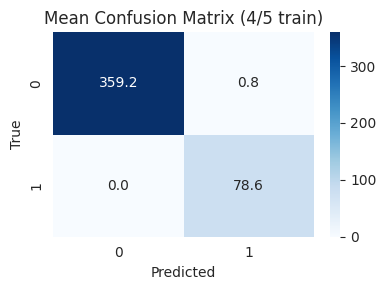


 TRAINING: 2/5 of data


--- Fold 0 ---
Confusion matrix:
[[343   0]
 [  0  96]]
Accuracy: 1.0000
APCER: 0.0000
BPCER: 0.0000
ACER: 0.0000

--- Fold 1 ---
Confusion matrix:
[[370   0]
 [  0  69]]
Accuracy: 1.0000
APCER: 0.0000
BPCER: 0.0000
ACER: 0.0000

--- Fold 2 ---
Confusion matrix:
[[360   1]
 [  0  78]]
Accuracy: 0.9977
APCER: 0.0000
BPCER: 0.0028
ACER: 0.0014

--- Fold 3 ---
Confusion matrix:
[[357   2]
 [  0  79]]
Accuracy: 0.9954
APCER: 0.0000
BPCER: 0.0056
ACER: 0.0028

--- Fold 4 ---
Confusion matrix:
[[366   1]
 [  0  71]]
Accuracy: 0.9977
APCER: 0.0000
BPCER: 0.0027
ACER: 0.0014

 MEAN RESULTS OVER 5 FOLDS
Mean Confusion Matrix:
[[359.2   0.8]
 [  0.   78.6]]

Mean Accuracy: 0.9982
Mean APCER:    0.0000
Mean BPCER:    0.0022
Mean ACER:     0.0011


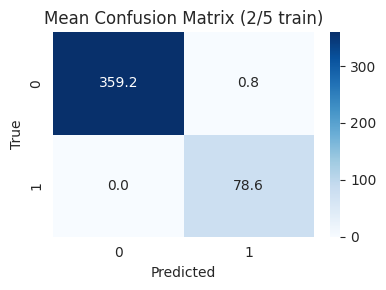


 TRAINING: 1/5 of data


--- Fold 0 ---
Confusion matrix:
[[343   0]
 [  0  96]]
Accuracy: 1.0000
APCER: 0.0000
BPCER: 0.0000
ACER: 0.0000

--- Fold 1 ---
Confusion matrix:
[[370   0]
 [  0  69]]
Accuracy: 1.0000
APCER: 0.0000
BPCER: 0.0000
ACER: 0.0000

--- Fold 2 ---
Confusion matrix:
[[360   1]
 [  0  78]]
Accuracy: 0.9977
APCER: 0.0000
BPCER: 0.0028
ACER: 0.0014

--- Fold 3 ---
Confusion matrix:
[[358   1]
 [  0  79]]
Accuracy: 0.9977
APCER: 0.0000
BPCER: 0.0028
ACER: 0.0014

--- Fold 4 ---
Confusion matrix:
[[366   1]
 [  0  71]]
Accuracy: 0.9977
APCER: 0.0000
BPCER: 0.0027
ACER: 0.0014

 MEAN RESULTS OVER 5 FOLDS
Mean Confusion Matrix:
[[359.4   0.6]
 [  0.   78.6]]

Mean Accuracy: 0.9986
Mean APCER:    0.0000
Mean BPCER:    0.0017
Mean ACER:     0.0008


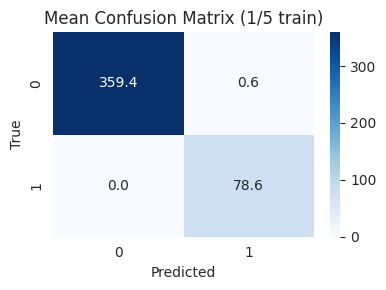


 FINAL SUMMARY TABLE
   train_folds  mean_accuracy  mean_apcer  mean_bpcer  mean_acer
0            4       0.998175         0.0    0.002213   0.001107
1            2       0.998175         0.0    0.002213   0.001107
2            1       0.998631         0.0    0.001656   0.000828


In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# Load histogram dataset
# ================================================================
csv_path = "/content/drive/MyDrive/PLUS/threshold_output_PLUS_fast.csv"
dataset = "PLUS_full"
df = pd.read_csv(csv_path)
df = df.fillna(0)

print("Dataset loaded:", df.shape)

# ================================================================
# Extract features and labels
# ================================================================
X = df[[c for c in df.columns if c.startswith("fd_")]].values
y = df["type"].values
subjects = df["filename"].values

# ================================================================
# Compute APCER / BPCER / ACER helper
# ================================================================
def compute_errors(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    APCER = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    BPCER = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    ACER = (APCER + BPCER) / 2
    return APCER, BPCER, ACER, cm

# ================================================================
# Visualization of confusion matrix
# ================================================================
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt=".1f", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# SAVE PLOTS
# ---------------------------------------------------------
def save_confusion_matrix(cm, title, save_path):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt=".1f", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
  # ---------------------------------------------------------
# RUN ALL THREE TRAIN FRACTIONS
# ---------------------------------------------------------
def run_all(df, csv_path):
    # extract dataset name automatically from file
    dataset_name = os.path.splitext(os.path.basename(csv_path))[0]
    out_dir = f"/content/drive/MyDrive/RESULTS_FD/{dataset}/{dataset_name}"
    os.makedirs(out_dir, exist_ok=True)

    results = []
    results.append(run_experiment(df, 4, out_dir))
    results.append(run_experiment(df, 2, out_dir))
    results.append(run_experiment(df, 1, out_dir))

    final_df = pd.DataFrame(results)
    final_df.to_csv(os.path.join(out_dir, "final_summary_PLUS_FULL_TRAIN.csv"), index=False)

    print("\n============================")
    print(" FINAL SUMMARY TABLE")
    print("============================")
    print(final_df)

    return final_df
# ================================================================
# SUBJECT-based 5-FOLD SPLITTING
# ================================================================

unique_subjects = np.array(sorted(np.unique(subjects)))
np.random.shuffle(unique_subjects)

# Split subjects into 5 nearly equal folds
subject_folds = np.array_split(unique_subjects, 5)

# We store folds like this:
# fold_subjects[i] = subjects used for testing in fold i
# training folds = all other folds
# Now we have 5 consistent folds:
# fold 0 ... fold 4 each containing subject IDs


# ================================================================
# RUN EVALUATION
# ================================================================
def run_experiment(df, train_fraction_folds, out_dir):

    print("\n==============================================")
    print(f" TRAINING: {train_fraction_folds}/5 of data")
    print("==============================================\n")

    fold_cm_list = []
    acc_list = []
    apcer_list = []
    bpcer_list = []
    acer_list = []


    # Ordner für diesen Trainingsanteil
    train_dir = os.path.join(out_dir, f"{train_fraction_folds}_of_5_train")
    os.makedirs(train_dir, exist_ok=True)
    # Für jeden Fold (0–4):
    for fold_id in range(5):

        print(f"\n--- Fold {fold_id} ---")

        # Test-Subjects = entire fold
        test_subjects = subject_folds[fold_id]

        # Die anderen 4 Folds
        other_folds = [i for i in range(5) if i != fold_id]

        # Zufällig train_fraction_folds Folds auswählen
        np.random.shuffle(other_folds)
        selected_train_folds = other_folds[:train_fraction_folds]

        # 🔥 FIX: ganze arrays nehmen, nicht einzelwerte
        train_subjects = np.concatenate([subject_folds[i] for i in selected_train_folds])

        # --- Mask bauen ---
        is_train = np.isin(subjects, train_subjects)
        is_test  = np.isin(subjects, test_subjects)

        X_train, X_test = X[is_train], X[is_test]
        y_train, y_test = y[is_train], y[is_test]

        # Normalize
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # KNN
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train_s, y_train)
        y_pred = knn.predict(X_test_s)

        # Metrics
        apcer, bpcer, acer, cm = compute_errors(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        acc = accuracy_score(y_test, y_pred)

        print("Confusion matrix:")
        print(cm)
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(f"APCER: {apcer:.4f}")
        print(f"BPCER: {bpcer:.4f}")
        print(f"ACER: {acer:.4f}")

        # Save individual CM
        save_confusion_matrix(
            cm,
            title=f"Fold {fold_id} Confusion Matrix ({train_fraction_folds}/5 train)",
            save_path=os.path.join(train_dir, f"cm_fold_{fold_id}.png")
        )

        fold_cm_list.append(cm)
        acc_list.append(acc)
        apcer_list.append(apcer)
        bpcer_list.append(bpcer)
        acer_list.append(acer)



    # ---------------------------------------------------------
    # AVERAGE RESULTS
    # ---------------------------------------------------------
    mean_cm = np.mean(fold_cm_list, axis=0)

    print("\n==============================================")
    print(" MEAN RESULTS OVER 5 FOLDS")
    print("==============================================")
    print("Mean Confusion Matrix:")
    print(mean_cm)

    save_confusion_matrix(
        mean_cm,
        title=f"Mean Confusion Matrix ({train_fraction_folds}/5 train)",
        save_path=os.path.join(train_dir, "cm_mean.png")
    )

    mean_acc   = np.mean(acc_list)
    mean_apcer = np.mean(apcer_list)
    mean_bpcer = np.mean(bpcer_list)
    mean_acer  = np.mean(acer_list)

    result = {
        "train_folds": train_fraction_folds,
        "mean_accuracy": mean_acc,
        "mean_apcer": mean_apcer,
        "mean_bpcer": mean_bpcer,
        "mean_acer": mean_acer
    }

    print(f"\nMean Accuracy: {mean_acc:.4f}")
    print(f"Mean APCER:    {mean_apcer:.4f}")
    print(f"Mean BPCER:    {mean_bpcer:.4f}")
    print(f"Mean ACER:     {mean_acer:.4f}")

    # Save metrics per run
    pd.DataFrame([result]).to_csv(os.path.join(train_dir, "metrics.csv"), index=False)



    # plot averaged confusion matrix
    plot_confusion_matrix(mean_cm, title=f"Mean Confusion Matrix ({train_fraction_folds}/5 train)")


    return result

results = run_all(df, csv_path)

In [21]:
# Full test with synthetic data
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from collections import defaultdict
import random
random.seed(42)
np.random.seed(42)

# X = df[[c for c in df.columns if c.startswith("fd_")]].values
# y = df["type"].values
# subjects = df["user_id"].values

def load_dataset(all_csv):
    data = pd.read_csv(all_csv)
    data = data.rename(
      columns={
          c: c.replace("fractal_dimension_seg", "fd_seg")
          for c in data.columns
          if c.startswith("fractal_dimension_seg")
      }
    )

    data = data.rename(
      columns={
          c: c.replace("fractal_dimension_", "fd_full_")
          for c in data.columns
          if c.startswith("fractal_dimension_")
      }
    )
    data.columns = data.columns.str.replace(r'\.0$', '', regex=True)
    data = data.fillna(0)
    return add_sequential_user_id(data)

def add_sequential_user_id(df):
    df = df.copy()
    df["user_id"] = range(1, len(df) + 1)
    return df

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    # print("===================")
    # print("Confusion matrix:")
    # print(cm)
    # print("Accuracy:", acc)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # apcer = BF incorrectly classified as attack
    apcer = fn / (tp + fn) if (tp + fn) > 0 else 0

    # bpcer = Attack incorrectly classified as bona fide
    bpcer = fp / (fp + tn) if (fp + tn) > 0 else 0

    acer = (apcer + bpcer) / 2
    '''
    print("APCER:", apcer)
    print("BPCER:", bpcer)
    print("ACER:", acer)
    '''

    return acc, acer, apcer, bpcer


def create_user_folds(data_df, n_splits=5):
    data = data_df.sample(frac=1, random_state=42).reset_index(drop=True).sample(frac=1, random_state=42).reset_index(drop=True)
    users = data["user_id"].unique()
    #print(users)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    folds = []
    for train_users_idx, test_users_idx in kf.split(users):
        train_users = users[train_users_idx]
        test_users = users[test_users_idx]

        train = data[data.user_id.isin(train_users)]
        test = data[data.user_id.isin(test_users)]
        folds.append((train, test))
    return folds

def run_knn(train_df, test_df, n_neighbors=5):
    X_train = train_df[[c for c in train_df.columns if c.startswith("fd_")]].values
    y_train = train_df["type"].values

    X_test = test_df[[c for c in test_df.columns if c.startswith("fd_")]].values
    y_test = test_df["type"].values

    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    return compute_metrics(y_test, y_pred)

def stepA_ground_truth(data):
    folds = create_user_folds(data)
    results = []

    for train, test in folds:
        metrics = run_knn(train, test)
        results.append(metrics)

    return np.mean(results, axis=0)

def convert_into_synthetic(training_df, synthetic_df):

    # 1️⃣ Count number of type==1 rows in training
    n = (training_df["type"] == 1).sum()

    # 2️⃣ Sample n rows with type==1 from synthetic
    synthetic_sample = (
        synthetic_df[synthetic_df["type"] == 1]
        .sample(n=n, replace=False, random_state=42)
        .reset_index(drop=True)
    )

    # 3️⃣ Randomly pick n rows with type==1 in training to replace
    train_type1_idx = (
        training_df[training_df["type"] == 1]
        .sample(n=n, replace=False, random_state=42)
        .index
    )

    # 4️⃣ Align indices and replace rows
    synthetic_sample.index = train_type1_idx
    training_df_copy = training_df.copy()
    training_df_copy.loc[train_type1_idx] = synthetic_sample

    return training_df_copy


def step_ground_truth_synthetic_all(data, synthetic):
    folds = create_user_folds(data)
    results_all = []
    results_1 =[]
    results_2 = []
    results_synthetic_all = []
    results_synthetic_3 = []
    results_synthetic_4 = []

    for train, test in folds:
        metrics = run_knn(train, test)
        results_all.append(metrics)

        users = train["user_id"].unique()

        # step 1
        k = max(1, int(len(users) * 2/4))
        #sampled_users = np.random.choice(users, k, replace=False)
        sampled_users = users[:k]
        train_sample = train[train.user_id.isin(sampled_users)]
        metrics = run_knn(train_sample, test)
        results_1.append(metrics)

        # step 2
        k = max(1, int(len(users) * 1/4))
        #sampled_users = np.random.choice(users, k, replace=False)
        sampled_users = users[:k]
        train_sample = train[train.user_id.isin(sampled_users)]
        metrics = run_knn(train_sample, test)
        results_2.append(metrics)

        # step 3 (1/5 - synthetic, 1/5 orig - spoof)

        k = max(1, int(len(users) * 2/4))
        sampled_users = users[:k] # np.random.choice(users, k, replace=False)
        synthetic_users = sampled_users[:int(k/2)] # np.random.choice(sampled_users, int(k/2), replace=False)
        train_sample = train[train.user_id.isin(synthetic_users)]
        train_synthetic = convert_into_synthetic(train_sample, synthetic)
        train_sample = train[train.user_id.isin(sampled_users[int(k/2):])]
        train_synthetic = pd.concat([train_sample, train_synthetic])
        metrics = run_knn(train_synthetic, test)
        results_synthetic_3.append(metrics)

        # step 4 (3/5 - synthetic, 1/5 orig - spoof)
        k = max(1, int(len(users) * 3/4))
        synthetic_users = users[:k] #np.random.choice(users, int(len(users) * (3/4)), replace=False)
        train_sample = train[train.user_id.isin(synthetic_users)]
        train_synthetic = convert_into_synthetic(train_sample, synthetic)
        train_sample = train[train.user_id.isin(~synthetic_users)]
        train_synthetic = pd.concat([train_sample, train_synthetic])
        metrics = run_knn(train_synthetic, test)
        results_synthetic_4.append(metrics)

        # step 5 (all synthetic - spoof)
        train_synthetic = convert_into_synthetic(train, synthetic)
        metrics_synthetic = run_knn(train_synthetic, test)
        results_synthetic_all.append(metrics_synthetic)


    return np.mean(results_all, axis=0), np.mean(results_1, axis=0), np.mean(results_2, axis=0), np.mean(results_synthetic_3, axis=0), np.mean(results_synthetic_4, axis=0), np.mean(results_synthetic_all, axis=0)

def step1_two_fifths_training(data):
    folds = create_user_folds(data)
    results = []

    for train_full, test in folds:
        # Randomly sample 2/5 of the training users
        users = train_full["user_id"].unique()
        k = max(1, int(len(users) * 2/5))
        sampled_users = np.random.choice(users, k, replace=False)

        train = train_full[train_full.user_id.isin(sampled_users)]

        metrics = run_knn(train, test)
        results.append(metrics)

    return np.mean(results, axis=0)

def step2_one_fifth_training(data):
    folds = create_user_folds(data)
    results = []

    for train_full, test in folds:
        # Sample 1/5 of training users
        users = train_full["user_id"].unique()
        k = max(1, int(len(users) * 1/5))
        sampled_users = np.random.choice(users, k, replace=False)

        train = train_full[train_full.user_id.isin(sampled_users)]

        metrics = run_knn(train, test)
        results.append(metrics)

    return np.mean(results, axis=0)

# synthetic data
def sample_synthetic_like(real_df, synthetic_df, n=None):
    """
    Returns random synthetic samples.
    If n is None -> same size as real_df
    """
    if n is None:
        n = len(real_df)

    # Prefer same users if overlap exists
    common_users = set(real_df.user_id.unique()) & set(synthetic_df.user_id.unique())

    if len(common_users) > 0:
        synth_subset = synthetic_df[synthetic_df.user_id.isin(common_users)]
    else:
        synth_subset = synthetic_df

    if len(synth_subset) >= n:
        return synth_subset.sample(n, random_state=42)
    else:
        # If fewer available → sample with replacement
        return synth_subset.sample(n, replace=True, random_state=42)

        # --------------------------------------------------
        # COUNT REAL SPOOF IN TRAIN
        # --------------------------------------------------
        n_real_spoof_train = (df_real_train.label == 1).sum()

        # --------------------------------------------------
        # SYNTHETIC SAMPLING (IMAGE-LEVEL)
        # --------------------------------------------------
        n_synth = int(round(replace_ratio * n_real_spoof_train))

        if n_synth > 0:
            df_synth_train = df_synth.sample(
                n=n_synth,
                replace=True,
                random_state=seed + fold_id
            )
        else:
            df_synth_train = df_synth.iloc[0:0]


def step3_add_synthetic_random(data, synthetic):
    folds = create_user_folds(data)
    results = []



    for train_full, test in folds:
        users = train_full["user_id"].unique()

        # Step-2 base = 1/5 real users
        k = max(1, int(len(users) * 1/5))
        base_users = np.random.choice(users, k, replace=False)

        base_train = train_full[train_full.user_id.isin(base_users)]
        removed_real = train_full[~train_full.user_id.isin(base_users)]

        # Add synthetic equal in size to removed real
        synthetic_part = sample_synthetic_like(removed_real, synthetic)

        train = pd.concat([base_train, removed_real, synthetic_part])

        metrics = run_knn(train, test)
        results.append(metrics)

    return np.mean(results, axis=0)




def step4_threefold_real_plus_synth_random(data, synthetic):
    folds = create_user_folds(data)
    results = []

    for train_full, test in folds:
        # Add synthetic equal in size to train_full
        synthetic_part = sample_synthetic_like(train_full, synthetic)

        train = pd.concat([train_full, synthetic_part])

        metrics = run_knn(train, test)
        results.append(metrics)

    return np.mean(results, axis=0)


def step5_real_plus_synth_only_random(data, synthetic):
    folds = create_user_folds(data)
    results = []

    for train_real, test in folds:
        synthetic_part = sample_synthetic_like(train_real, synthetic)

        train = pd.concat([train_real, synthetic_part])

        metrics = run_knn(train, test)
        results.append(metrics)

    return np.mean(results, axis=0)

def print_results(file_path, file_synthetic_real):

  # file_path = "/content/drive/MyDrive/SCUT/full/dev/threshold_output_SCUT.csv"
  real_fake_data = load_dataset(file_path)
  print("Data count:",  real_fake_data.shape)
  # file_synthetic_real = "/content/drive/MyDrive/AE_Res-diff/SCUT/threshold_output_SCUT_fast.csv"

  synthetic_real = pd.read_csv(file_synthetic_real)
  synthetic_all = synthetic_real #pd.concat([synthetic_real, synthetic_fake])
  synthetic_all = synthetic_all.fillna(0)
  synthetic_all = add_sequential_user_id(synthetic_all)

  print("==============================================")
  print("file_path:",file_path)
  print("file_synthetic", file_synthetic_real)

  real_all, real_1, real_2, synthetic_3, synthetic_4, synthetic_all = step_ground_truth_synthetic_all(real_fake_data, synthetic_all )

  print("Step real all:", real_all)
  print("Real Step 1:", real_1)
  print("Real Step 2:", real_2)
  print("Synthetic Step 3:", synthetic_3)
  print("Synthetic Step 4:", synthetic_4)
  print("Synthetic Step 5:", synthetic_all)
  print("==============================================")

print_results("/content/drive/MyDrive/SCUT/full/dev/threshold_output_SCUT.csv", "/content/drive/MyDrive/AE_Res-diff/SCUT/threshold_output_SCUT_fast.csv")





Data count: (1455, 84)
file_path: /content/drive/MyDrive/SCUT/full/dev/threshold_output_SCUT.csv
file_synthetic /content/drive/MyDrive/AE_Res-diff/SCUT/threshold_output_SCUT_fast.csv
Step real all: [0.96907216 0.03107503 0.00273973 0.05941034]
Real Step 1: [0.94570447 0.05466145 0.0218264  0.0874965 ]
Real Step 2: [0.92783505 0.07266506 0.02564582 0.1196843 ]
Synthetic Step 3: [0.94020619 0.06011884 0.02714926 0.09308843]
Synthetic Step 4: [0.94364261 0.05648003 0.03517379 0.07778627]
Synthetic Step 5: [0.94845361 0.05149886 0.03101643 0.07198128]


In [22]:
# print the results
# PLUS
print_results("/content/drive/MyDrive/PLUS/threshold_output_PLUS_fast.csv", "/content/drive/MyDrive/VAE-diff/PLUS_matched/threshold_output_PLUS_matched_fast.csv")
print_results("/content/drive/MyDrive/PLUS/threshold_output_PLUS_fast.csv", "/content/drive/MyDrive/AE_Res-diff/PLUS_matched/threshold_output_PLUS_matched_fast.csv")

# SCUT train
print_results("/content/drive/MyDrive/SCUT/full/train/threshold_output_SCUT_train_fast.csv","/content/drive/MyDrive/VAE-diff/SCUT/threshold_output_SCUT_spoof.csv")
print_results("/content/drive/MyDrive/SCUT/full/train/threshold_output_SCUT_train_fast.csv","/content/drive/MyDrive/AE_Res-diff/SCUT/threshold_output_SCUT_fast.csv")

# SCUT DEV
print_results("/content/drive/MyDrive/SCUT/full/dev/threshold_output_SCUT.csv","/content/drive/MyDrive/VAE-diff/SCUT/threshold_output_SCUT_spoof.csv")
print_results("/content/drive/MyDrive/SCUT/full/dev/threshold_output_SCUT.csv","/content/drive/MyDrive/AE_Res-diff/SCUT/threshold_output_SCUT_fast.csv")

# IDIAP train
print_results("/content/drive/MyDrive/IDIAP/full/train/threshold_output_IDIAP_train_fast.csv","/content/drive/MyDrive/VAE-diff/IDIAP/threshold_output_IDIAP_fast.csv")
print_results("/content/drive/MyDrive/IDIAP/full/train/threshold_output_IDIAP_train_fast.csv","/content/drive/MyDrive/AE_Res-diff/IDIAP/threshold_output_IDIAP_fast.csv")

# IDIAP DEV
print_results("/content/drive/MyDrive/IDIAP/full/dev/threshold_output_IDIAP.csv","/content/drive/MyDrive/VAE-diff/IDIAP/threshold_output_IDIAP_fast.csv")
print_results("/content/drive/MyDrive/IDIAP/full/dev/threshold_output_IDIAP.csv","/content/drive/MyDrive/AE_Res-diff/IDIAP/threshold_output_IDIAP_fast.csv")



Data count: (2193, 84)
file_path: /content/drive/MyDrive/PLUS/threshold_output_PLUS_fast.csv
file_synthetic /content/drive/MyDrive/VAE-diff/PLUS_matched/threshold_output_PLUS_matched_fast.csv
Step real all: [0.99726339 0.00261642 0.00243902 0.00279382]
Real Step 1: [0.99680885 0.00194485 0.         0.00388971]
Real Step 2: [0.99225096 0.01927134 0.03741273 0.00112994]
Synthetic Step 3: [0.99544003 0.00372158 0.00243902 0.00500413]
Synthetic Step 4: [0.99726339 0.00261642 0.00243902 0.00279382]
Synthetic Step 5: [0.99726339 0.00261642 0.00243902 0.00279382]
Data count: (2193, 84)
file_path: /content/drive/MyDrive/PLUS/threshold_output_PLUS_fast.csv
file_synthetic /content/drive/MyDrive/AE_Res-diff/PLUS_matched/threshold_output_PLUS_matched_fast.csv
Step real all: [0.99726339 0.00261642 0.00243902 0.00279382]
Real Step 1: [0.99680885 0.00194485 0.         0.00388971]
Real Step 2: [0.99225096 0.01927134 0.03741273 0.00112994]
Synthetic Step 3: [0.99452887 0.0061801  0.00735607 0.00500413]